### import libaries

In [1]:
import os
import sys
os.environ['PYTHONPATH'] = 'PYTHONPATH=/pbs/home/o/omacias/Sam_project' ##Refix  
print(os.environ['PYTHONPATH'])
sys.path.append('/pbs/home/o/omacias/Sam_project')
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
from scipy.signal import hilbert

### Model import
from raytune_lib_final.training.models.cnn import DualBranchAutoencoder as CNN
from raytune_lib_final.training.raytune_training_function import CustomDataset, split_indices, psnr, plot_snr_distribution
from raytune_lib_final.visualization.overleaf_plots import (peak_amplitude_analysis_all_channels, 
                                                            traces_plot_time_frequency, 
                                                            peak_time_analysis_for_all_channels)
from raytune_lib_final.utils.data_preprocessing import produce_noise_and_noiseless_data

PYTHONPATH=/pbs/home/o/omacias/Sam_project


/sps/grand/macias/conda_envs/ili-torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-21 06:45:38,736	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-21 06:45:39,876	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


### test_loader


In [2]:
## Load Sim data
Sim_data = "/sps/grand/blevy/sims/sims_for_denoising_sept2025" ### (3, n_noise_samples, 1024)
noise_signals, clean_signals = produce_noise_and_noiseless_data(Sim_data)

total_samples_train = clean_signals.shape[1]
train_indices, valid_indices, test_indices = split_indices(total_samples_train, train_frac=0.8, valid_frac=0.1)
# With swapping enabled (default 50% probability)

train_dataset = CustomDataset(clean_signals, [noise_signals], indices=train_indices, 
                       swap_prob=0.5, target_start=120, target_end=480)

valid_dataset = CustomDataset(clean_signals, [noise_signals], indices=valid_indices, 
                       swap_prob=0.5, target_start=120, target_end=480)

test_dataset = CustomDataset(clean_signals, [noise_signals], indices=test_indices, 
                       swap_prob=0.5, target_start=120, target_end=480, voltage_to_adc=True)
print(f'shape of test_indices {np.shape(test_indices)}')


test_loader = DataLoader(test_dataset, batch_size=1, num_workers=0, shuffle=False, pin_memory=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Device set to : {device}')
save_path= '/pbs/home/o/omacias/Sam_project/raytune_lib_final/output'


Loaded noise file 0: shape (3, 12500, 1024)
Noise signals shape: (3, 300000, 1024)
Clean signals shape: (3, 410673, 1024)
shape of test_indices (41068,)
Device set to : cpu


### Clean and Noisy Waveform

In [3]:
### Generate noise_only.npy and save clean/noisy files for FPR analysis

# Import functions from false_positive_rate_and_plot
sys.path.insert(0, '/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization/false_positive_rate_and_plot')
from false_positive_rate_and_plot import (
    build_noise_only_traces,
    Config as FPRConfig
)

# Collect test set data (using test_loader)
collect_loader = DataLoader(test_dataset, batch_size=1, num_workers=0, shuffle=False, pin_memory=False)

noisy_data_list = []
clean_data_list = []

for noisy_signals, clean_signals_batch in collect_loader:
    noisy_np = noisy_signals.squeeze(0).numpy()   # (3, T)
    clean_np = clean_signals_batch.squeeze(0).numpy()  # (3, T)
    
    noisy_data_list.append(noisy_np)
    clean_data_list.append(clean_np)

# Stack into (N, 3, T) format - this is the format required by false_positive_rate_and_plot.py
noisy_array = np.stack(noisy_data_list, axis=0)   # (N, 3, T)
clean_array = np.stack(clean_data_list, axis=0)   # (N, 3, T)

print(f"clean_array shape: {clean_array.shape}")   # Should be (N, 3, T)
print(f"noisy_array shape: {noisy_array.shape}")   # Should be (N, 3, T)

# Set FPR configuration
fpr_cfg = FPRConfig(
    dt_ns=2.0,
    sig_half_width_ns=150.0,
    guard_half_width_ns=150.0,
    chunk_len=256,
    seed=12345,
)

# Build noise-only traces
noise_only, peak_idx, sig_lo, sig_hi = build_noise_only_traces(clean_array, noisy_array, fpr_cfg)

print(f"noise_only shape: {noise_only.shape}")

# Save files
output_dir = '/pbs/home/o/omacias/Sam_project/raytune_lib_final/output'
np.save(os.path.join(output_dir, 'clean_waveforms.npy'), clean_array)
np.save(os.path.join(output_dir, 'noisy_waveforms.npy'), noisy_array)
np.save(os.path.join(output_dir, 'noise_only.npy'), noise_only)
np.savez(
    os.path.join(output_dir, 'noise_only_meta.npz'),
    peak_idx=peak_idx,
    sig_lo=sig_lo,
    sig_hi=sig_hi,
)

print(f"[OK] Saved: clean_waveforms.npy, noisy_waveforms.npy, noise_only.npy")
print(f"[OK] Next step: run denoiser on noise_only.npy to generate denoised_noise_only.npy")

clean_array shape: (41068, 3, 512)
noisy_array shape: (41068, 3, 512)
noise_only shape: (41068, 3, 512)
[OK] Saved: clean_waveforms.npy, noisy_waveforms.npy, noise_only.npy
[OK] Next step: run denoiser on noise_only.npy to generate denoised_noise_only.npy


### plot histogram 

/pbs/home/o/omacias/.local/lib/python3.10/site-packages/numpy/core/_methods.py:152: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/pbs/home/o/omacias/.local/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


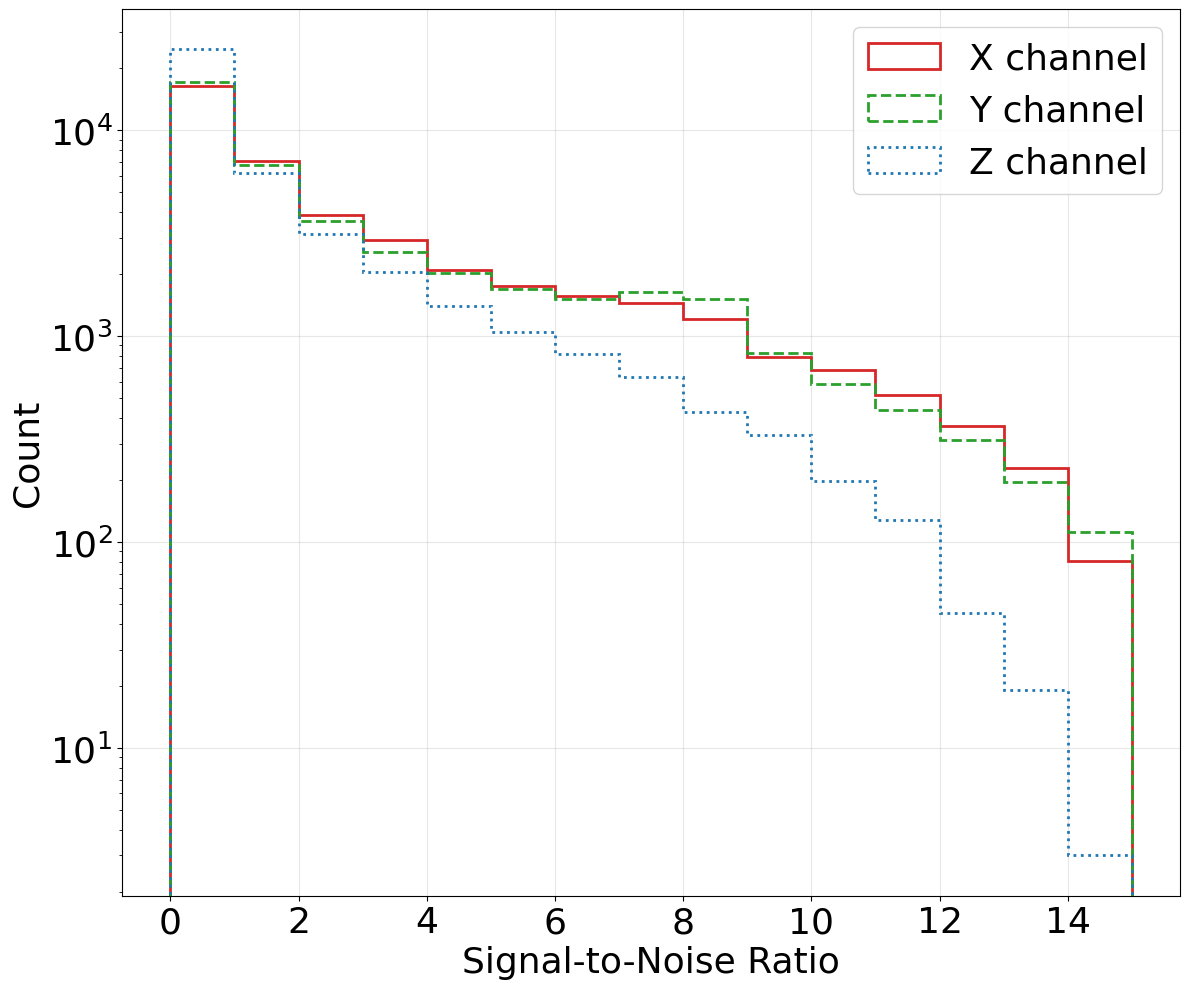

In [3]:
# Create a DataLoader without multiprocessing for data collection
collect_loader = DataLoader(valid_dataset, batch_size=1, num_workers=0, shuffle=False, pin_memory=False)

noised_data_list = []
clean_data_list = []

# Iterate through the collect_loader
for noised_signals, clean_signals in collect_loader:
    noised_np = noised_signals.squeeze(0).numpy()  # (3, traces_len)
    clean_np = clean_signals.squeeze(0).numpy()    # (3, traces_len)
    
    noised_data_list.append(noised_np)
    clean_data_list.append(clean_np)

# Stack all samples into arrays with shape (3, n_samples, traces_len)
noised_signals_array = np.stack(noised_data_list, axis=1)  # (3, n_samples, traces_len)
clean_signals_array = np.stack(clean_data_list, axis=1)    # (3, n_samples, traces_len)

# Now plot the histogram
plot_snr_distribution(noised_signals_array, clean_signals_array, save_folder=save_path)

### Best CNN Model

In [2]:
def load_best_trial_from_files(metrics_json_path: str,
                               config_json_path: str,
                               model_path: str,
                               model_classes: dict,
                               device: str = "cpu"):
    """
    Load best trial metrics, config (incl. model_config), and the trained model.

    Args:
        metrics_json_path: Path to best_trial_metrics.json
        config_json_path: Path to best_trial_config.json (contains model_config and model_type)
        model_path: Path to best_model.pth
        model_classes: Dict mapping model_type -> class, e.g. {"CNN": CNN, "SingleBranchCNN": SingleBranchCNN}
        device: 'cpu' or CUDA device string, e.g. 'cuda:0'

    Returns:
        (metrics_dict, config_dict, model) tuple
    """
    # Load metrics and config
    with open(metrics_json_path, "r") as f:
        metrics = json.load(f)
    with open(config_json_path, "r") as f:
        config = json.load(f)

    model_type = config.get("model_type")
    model_config = config.get("model_config")
    if model_type not in model_classes:
        raise ValueError(f"Unknown model_type '{model_type}'. Available: {list(model_classes.keys())}")
    if model_config is None:
        raise ValueError("model_config missing in best_trial_config.json")

    # Build model
    ModelClass = model_classes[model_type]
    model = ModelClass(model_config)
    model.to(device)
    model.eval()

    # Load weights (handle PyTorch versions without weights_only)
    try:
        state = torch.load(model_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)

    return metrics, config, model


def traces_plot_v1(testloader, 
         model, 
         num_images = 12, 
         device="cpu",
         save_path = ''
        ):
    """
    Plot the traces of the clean, noisy and denoised signals for 1 row with 3 channels of images,
    sharing x and y axes, with shared axis labels.
    """
    with torch.no_grad():  
        device = torch.device(device)
        model = model.to(device)
        model.eval() 
        count = 0  # To count the number of images saved
        for noisy_data, clean_data in testloader:
            if count >= num_images: 
                break
            
            noisy_data, clean_data = noisy_data.to(device), clean_data.to(device)
            denoised_output = model(noisy_data)
            
            batch_size = noisy_data.size(0)
            for sample_idx in range(batch_size):
                if count >= num_images:
                    break
                
                # Check SNR and peak amplitude for all channels first
                valid_sample = True
                snrs = []
                peak_amps = []
                
                for channel_idx in range(3):
                    clean_np = clean_data[sample_idx, channel_idx].cpu().numpy()
                    noisy_np = noisy_data[sample_idx, channel_idx].cpu().numpy()
                    
                    # Calculate SNR
                    if np.std(noisy_np) != 0:
                        snr = np.max(clean_np) / np.std(noisy_np)
                    else:
                        snr = float('inf')
                    
                    # Calculate peak amplitude
                    envelope_clean = np.abs(hilbert(clean_np))
                    peak_amp = np.max(envelope_clean)
                    
                    snrs.append(snr)
                    peak_amps.append(peak_amp)
                    
                    # Check if this channel meets criteria
                    if snr <= 1 or peak_amp <= 0:
                        valid_sample = False
                        break
                
                # Only plot if all channels meet criteria
                if not valid_sample:
                    continue
                    
                channel_names = ['X Channel', 'Y Channel', 'Z Channel']
                fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True, sharey=True)
                
                for channel_idx in range(3): 
                    ax = axes[channel_idx]
                    fontsize = 16
                    clean_np = clean_data[sample_idx, channel_idx].cpu().numpy()
                    noisy_np = noisy_data[sample_idx, channel_idx].cpu().numpy()
                    denoised_np = denoised_output[sample_idx, channel_idx].cpu().numpy()
                    snr = snrs[channel_idx]

                    psnr_value = psnr(clean_np, denoised_np, np.max(clean_np))
                    time_bin = np.arange(0, clean_np.size)
                    envelope_true = np.abs(hilbert(clean_np))
                    peak_time_true = time_bin[np.argmax(envelope_true)]
                    
                    ax.plot(noisy_np, label='Noisy', linestyle='--', color='orange', alpha=0.4)
                    ax.plot(clean_np, label='True', color='red', alpha=0.8)
                    ax.plot(denoised_np, label='Denoised', color='blue', alpha=0.5)
                    ax.axhline(y = np.std(noisy_np), color='black', linestyle='--')
                    ax.axhline(y = -np.std(noisy_np), color='black', linestyle='--')
                    # ax.set_xlim(peak_time_true - 125, peak_time_true + 200)
                    ax.text(
                            0.02, 0.95,
                            f"{channel_names[channel_idx]}",
                            transform=ax.transAxes,
                            fontsize=fontsize,
                            verticalalignment='top',
                            horizontalalignment='left',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                        )
                    if channel_idx == 0:
                            legend = ax.legend(fontsize=fontsize-4)
                            legend.get_frame().set_edgecolor('none')
                    ax.tick_params(axis='both', labelsize=fontsize)

                # Shared axis labels
                fig.text(0.5, 0.04, 'Time [ns]', ha='center', va='center', fontsize=fontsize+2)
                fig.text(0.04, 0.5, 'ADC counts', ha='center', va='center', rotation='vertical', fontsize=fontsize+2)
                plt.tight_layout(rect=[0.06, 0.06, 1, 1])
                if save_path:
                    plt.savefig(os.path.join(save_path, f'sample_{count:03d}_noisy.pdf'))
                    plt.close()
                else:
                    plt.show()
            count += 1
            if count >= num_images:
                break
    print('test is completed')




### Multi-L1

In [3]:
parent_dir = '/sps/grand/macias/Sam_Result/'
multi_l1_metrics_json = os.path.join(parent_dir, 'multi_v3_CNN_100epochs_36samples', 'best_trial_metrics.json')
multi_l1_config_json  = os.path.join(parent_dir, 'multi_v3_CNN_100epochs_36samples', 'best_trial_config.json')
multi_l1_model_path   = os.path.join(parent_dir, 'multi_v3_CNN_100epochs_36samples', 'best_model.pth')

model_classes = {"CNN": CNN}

multi_l1_metrics, multi_l1_config, multi_l1_model = load_best_trial_from_files(
    metrics_json_path=multi_l1_metrics_json,
    config_json_path=multi_l1_config_json,
    model_path=multi_l1_model_path,
    model_classes=model_classes,
    device="cpu"
)
multi_l1_save_path = os.path.join(parent_dir, 'multi_v3_CNN_100epochs_36samples','Test_Sample_plots' )
os.makedirs(multi_l1_save_path, exist_ok=True)



### Generate denoised_signal.npy from noisy_waveform.npy 

In [5]:
### Generate denoised_signal.npy and denoised_noise_only.npy using the ML model

# Output directory
output_dir = '/pbs/home/o/omacias/Sam_project/raytune_lib_final/output'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Load the saved noisy waveforms and noise-only traces
noisy_waveforms = np.load(os.path.join(output_dir, 'noisy_waveforms.npy'))  # (N, 3, T)
noise_only = np.load(os.path.join(output_dir, 'noise_only.npy'))            # (N, 3, T)

print(f"noisy_waveforms shape: {noisy_waveforms.shape}")
print(f"noise_only shape: {noise_only.shape}")

# Function to run inference in batches
def run_inference(model, data, device, batch_size=64):
    """
    Run model inference on data array (N, 3, T).
    Returns denoised output with same shape.
    """
    model.eval()
    model.to(device)
    
    N = data.shape[0]
    denoised_list = []
    
    with torch.no_grad():
        for i in range(0, N, batch_size):
            batch = data[i:i+batch_size]
            batch_tensor = torch.from_numpy(batch).float().to(device)
            output = model(batch_tensor)
            denoised_list.append(output.cpu().numpy())
            
            if (i // batch_size + 1) % 100 == 0:
                print(f"  Processed {i + len(batch)}/{N} samples...")
    
    return np.concatenate(denoised_list, axis=0)

# Run inference on noisy waveforms (signal-present)
print("Running inference on noisy_waveforms (signal-present)...")
denoised_signal = run_inference(multi_l1_model, noisy_waveforms, device, batch_size=64)
print(f"denoised_signal shape: {denoised_signal.shape}")

# Run inference on noise-only traces
print("Running inference on noise_only traces...")
denoised_noise_only = run_inference(multi_l1_model, noise_only, device, batch_size=64)
print(f"denoised_noise_only shape: {denoised_noise_only.shape}")

# Save the denoised outputs
np.save(os.path.join(output_dir, 'denoised_signal.npy'), denoised_signal)
np.save(os.path.join(output_dir, 'denoised_noise_only.npy'), denoised_noise_only)

print(f"[OK] Saved: denoised_signal.npy")
print(f"[OK] Saved: denoised_noise_only.npy")
print(f"[OK] Ready to run false_positive_rate_and_plot.py Step 3")

noisy_waveforms shape: (41068, 3, 512)
noise_only shape: (41068, 3, 512)
Running inference on noisy_waveforms (signal-present)...
  Processed 6400/41068 samples...
  Processed 12800/41068 samples...
  Processed 19200/41068 samples...
  Processed 25600/41068 samples...
  Processed 32000/41068 samples...
  Processed 38400/41068 samples...
denoised_signal shape: (41068, 3, 512)
Running inference on noise_only traces...
  Processed 6400/41068 samples...
  Processed 12800/41068 samples...
  Processed 19200/41068 samples...
  Processed 25600/41068 samples...
  Processed 32000/41068 samples...
  Processed 38400/41068 samples...
denoised_noise_only shape: (41068, 3, 512)
[OK] Saved: denoised_signal.npy
[OK] Saved: denoised_noise_only.npy
[OK] Ready to run false_positive_rate_and_plot.py Step 3


### False Positive Rate and Generate PRD Panel Figure

clean shape: (41068, 3, 512)
noisy shape: (41068, 3, 512)
noise_only shape: (41068, 3, 512)
sig_ml (denoised signal) shape: (41068, 3, 512)
noise_ml (denoised noise-only) shape: (41068, 3, 512)
Applying bandpass filter...
Estimating noise sigma...
Computing scan statistics...
T_sig_in (noisy): min=2.75, max=2176.92
T_sig_ml: min=0.14, max=2191.38
T_noise_in: min=2.83, max=6.95
T_noise_ml: min=0.14, max=4.53
SNR range: [0.25, 2176.85]

Per-method threshold calibration:
P_FA = 1e-02 -> tau_noisy_input = 5.28, tau_ml = 2.14
P_FA = 1e-03 -> tau_noisy_input = 5.94, tau_ml = 3.56
P_FA = 1e-04 -> tau_noisy_input = 6.41, tau_ml = 4.07
[OK] wrote /pbs/home/o/omacias/Sam_project/raytune_lib_final/output/tau_vs_pfa__noisy_input.pdf
[OK] wrote /pbs/home/o/omacias/Sam_project/raytune_lib_final/output/tau_vs_pfa__ml_denoiser.pdf
[OK] Saved taus_per_method.txt
[OK] wrote /pbs/home/o/omacias/Sam_project/raytune_lib_final/output/pd_vs_snr__pfa_1e-02.pdf
[OK] Saved /pbs/home/o/omacias/Sam_project/raytun

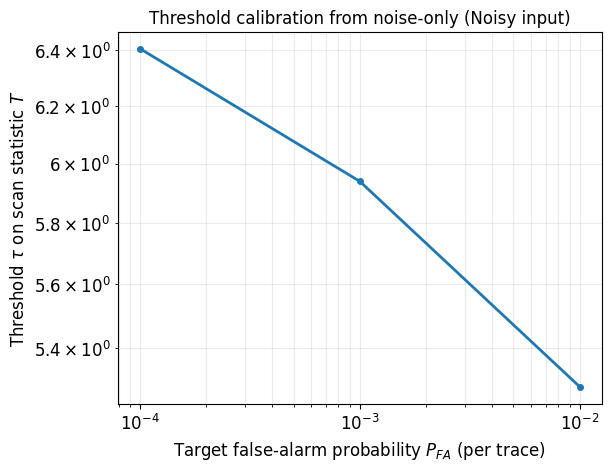

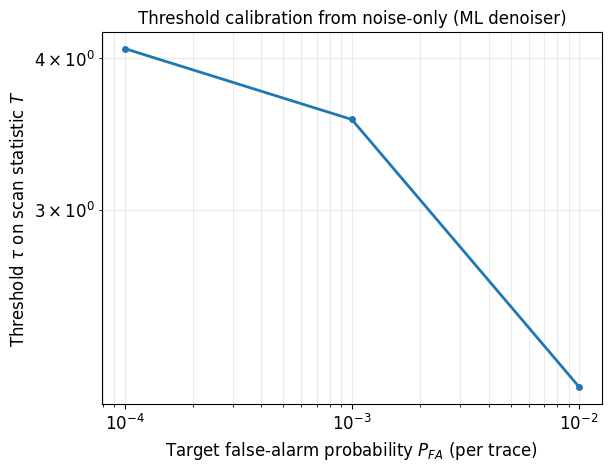

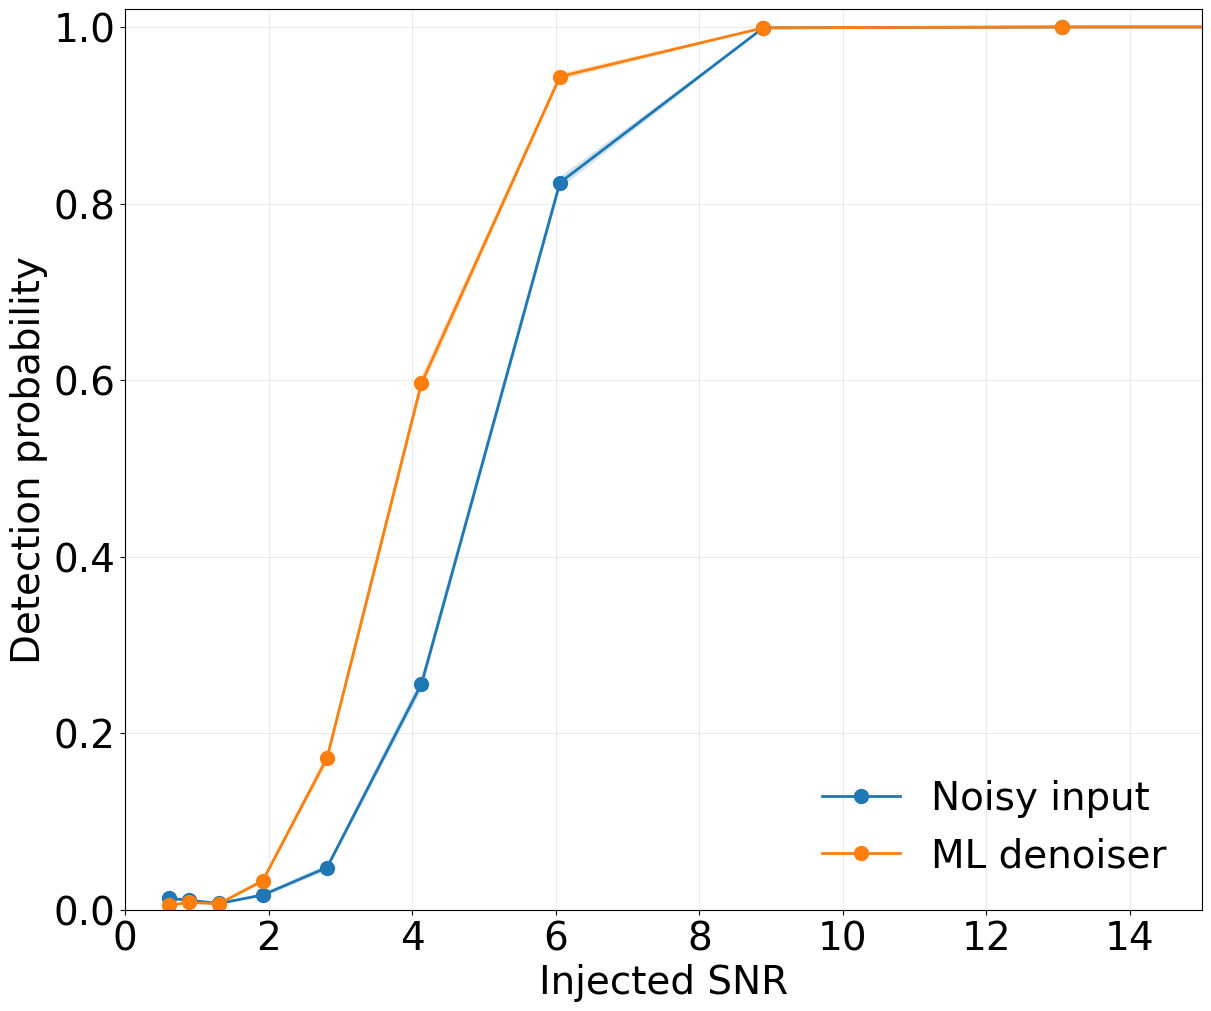

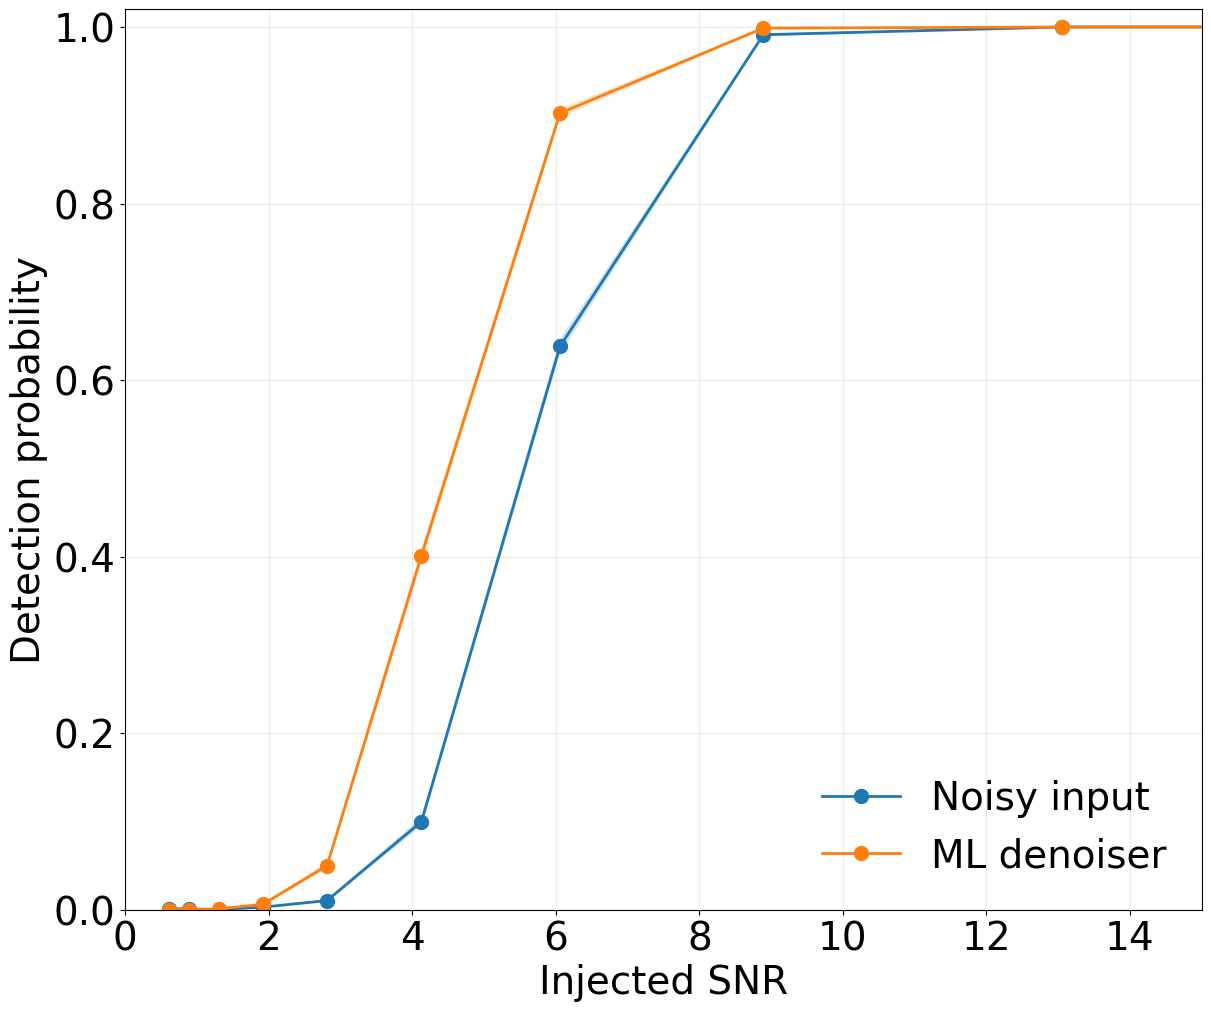

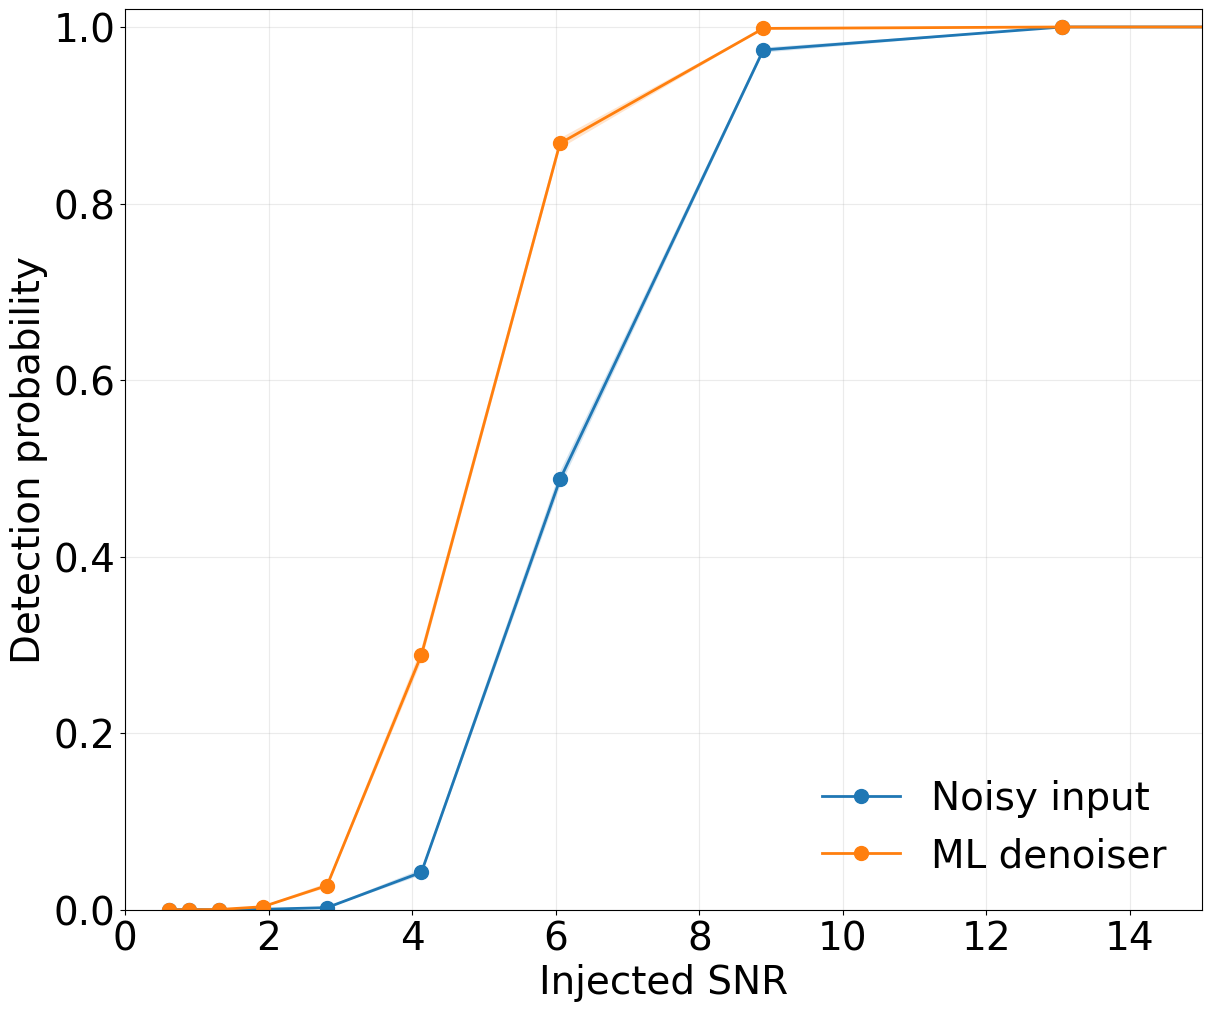

In [2]:
### Step 3 (v3): Compute P_D(SNR) at fixed P_FA - Per-Method Threshold Calibration

# Import functions from false_positive_rate_and_plot_v3
sys.path.insert(0, '/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization/false_positive_rate_and_plot')
from false_positive_rate_and_plot_v3 import (
    Cfg,
    bandpass_3d,
    sigma_in_from_input,
    scan_statistic,
    snr_from_clean,
    snr_edges,
    pd_vs_snr,
    tau_from_pfa,
    setup_matplotlib,
    plot_pd_vs_snr,
    plot_tau_vs_pfa,
)

# Output directory
output_dir = '/pbs/home/o/omacias/Sam_project/raytune_lib_final/output'

# Load all required arrays
clean = np.load(os.path.join(output_dir, 'clean_waveforms.npy'))           # (N, 3, T)
noisy = np.load(os.path.join(output_dir, 'noisy_waveforms.npy'))           # (N, 3, T)
noise_only = np.load(os.path.join(output_dir, 'noise_only.npy'))           # (N, 3, T)
sig_ml = np.load(os.path.join(output_dir, 'denoised_signal.npy'))          # (N, 3, T)
noise_ml = np.load(os.path.join(output_dir, 'denoised_noise_only.npy'))    # (N, 3, T)

# Load noise-only metadata (contains sig_lo, sig_hi for proper sigma estimation)
meta = np.load(os.path.join(output_dir, 'noise_only_meta.npz'))
sig_lo = meta['sig_lo']
sig_hi = meta['sig_hi']

print(f"clean shape: {clean.shape}")
print(f"noisy shape: {noisy.shape}")
print(f"noise_only shape: {noise_only.shape}")
print(f"sig_ml (denoised signal) shape: {sig_ml.shape}")
print(f"noise_ml (denoised noise-only) shape: {noise_ml.shape}")

# Configuration
cfg = Cfg(
    dt_ns=2.0,
    sig_half_width_ns=150.0,
    guard_half_width_ns=150.0,
    chunk_len=256,
    seed=12345,
    apply_bandpass=True,
    f_lo_hz=50e6,
    f_hi_hz=200e6,
    butter_order=4,
    snr_min=0.5,
    snr_max=50.0,
    snr_nbins=12,
    ci_alpha=0.32,  # 68% credible interval
    dpi=300,
)

setup_matplotlib(cfg)

# Bandpass all waveforms
print("Applying bandpass filter...")
noisy_bp = bandpass_3d(noisy, cfg)
clean_bp = bandpass_3d(clean, cfg)
sig_ml_bp = bandpass_3d(sig_ml, cfg)
noise_only_bp = bandpass_3d(noise_only, cfg)
noise_ml_bp = bandpass_3d(noise_ml, cfg)

# Estimate sigma_in from input traces
# For signal-present: estimate from off-pulse samples
# For noise-only: estimate from full trace
print("Estimating noise sigma...")
sigma_sig_in = sigma_in_from_input(noisy_bp, sig_lo=sig_lo, sig_hi=sig_hi, cfg=cfg)      # (N, 3)
sigma_noise_in = sigma_in_from_input(noise_only_bp, sig_lo=None, sig_hi=None, cfg=cfg)   # (N, 3)

# Compute scan statistics (detection scores)
print("Computing scan statistics...")
# Scores on signal-present
T_sig_in = scan_statistic(noisy_bp, sigma_sig_in, cfg)       # (N,) - noisy input
T_sig_ml = scan_statistic(sig_ml_bp, sigma_sig_in, cfg)      # (N,) - ML denoiser

# Scores on noise-only (H0) - for threshold calibration
T_noise_in = scan_statistic(noise_only_bp, sigma_noise_in, cfg)  # (N,)
T_noise_ml = scan_statistic(noise_ml_bp, sigma_noise_in, cfg)    # (N,)

print(f"T_sig_in (noisy): min={T_sig_in.min():.2f}, max={T_sig_in.max():.2f}")
print(f"T_sig_ml: min={T_sig_ml.min():.2f}, max={T_sig_ml.max():.2f}")
print(f"T_noise_in: min={T_noise_in.min():.2f}, max={T_noise_in.max():.2f}")
print(f"T_noise_ml: min={T_noise_ml.min():.2f}, max={T_noise_ml.max():.2f}")

# Compute injected SNR from CLEAN peak / sigma_in
SNR = snr_from_clean(clean_bp, sigma_sig_in, cfg)
print(f"SNR range: [{SNR.min():.2f}, {SNR.max():.2f}]")

# Define target false-alarm probabilities
pfas = np.array([1e-2, 1e-3, 1e-4], dtype=np.float64)

# Per-method threshold calibration (key change from v1!)
# Each method gets its own tau calibrated from its own H0 distribution
print("\nPer-method threshold calibration:")
taus_in = np.array([tau_from_pfa(T_noise_in, p) for p in pfas], dtype=np.float64)
taus_ml = np.array([tau_from_pfa(T_noise_ml, p) for p in pfas], dtype=np.float64)

for i, pfa in enumerate(pfas):
    print(f"P_FA = {pfa:.0e} -> tau_noisy_input = {taus_in[i]:.2f}, tau_ml = {taus_ml[i]:.2f}")

# SNR bin edges
edges = snr_edges(cfg)

# Plot tau vs pfa per method (separate plots for each method)
plot_tau_vs_pfa(
    os.path.join(output_dir, "tau_vs_pfa__noisy_input.pdf"),
    pfas, taus_in,
    r"Threshold calibration from noise-only (Noisy input)",
    cfg
)
plot_tau_vs_pfa(
    os.path.join(output_dir, "tau_vs_pfa__ml_denoiser.pdf"),
    pfas, taus_ml,
    r"Threshold calibration from noise-only (ML denoiser)",
    cfg
)

# Save threshold table (per-method)
np.savetxt(
    os.path.join(output_dir, "taus_per_method.txt"),
    np.column_stack([pfas, taus_in, taus_ml]),
    header="PFA  tau_noisy_input  tau_ml_denoiser",
)
print(f"[OK] Saved taus_per_method.txt")

# Generate P_D(SNR) plots for each P_FA using per-method thresholds
for i, pfa in enumerate(pfas):
    # Each method uses its own calibrated threshold
    det_in = (T_sig_in >= taus_in[i])
    det_ml = (T_sig_ml >= taus_ml[i])
    
    curves = {
        "Noisy input": pd_vs_snr(SNR, det_in, edges, cfg),
        "ML denoiser": pd_vs_snr(SNR, det_ml, edges, cfg),
    }
    
    tag = f"pfa_{pfa:.0e}".replace("+", "")
    out_pdf = os.path.join(output_dir, f"pd_vs_snr__{tag}.pdf")
    plot_pd_vs_snr(out_pdf, float(pfa), curves, cfg)
    
    # Save numerical data
    out_npz = os.path.join(output_dir, f"pd_vs_snr__{tag}.npz")
    np.savez(
        out_npz,
        pfa=float(pfa),
        tau_noisy=float(taus_in[i]),
        tau_ml=float(taus_ml[i]),
        snr_edges=edges,
        **{f"{k}__{kk}": vv for k, d in curves.items() for kk, vv in d.items()},
    )
    print(f"[OK] Saved {out_npz}")

print("[DONE] Generated per-P_FA P_D(SNR) plots with per-method threshold calibration.")

### Multi-MSE

In [8]:
multi_mse_metrics_json = os.path.join(parent_dir, 'multi_v2_CNN_100epochs_36samples', 'best_trial_metrics.json')
multi_mse_config_json  = os.path.join(parent_dir, 'multi_v2_CNN_100epochs_36samples', 'best_trial_config.json')
multi_mse_model_path   = os.path.join(parent_dir, 'multi_v2_CNN_100epochs_36samples', 'best_model.pth')

model_classes = {"CNN": CNN}

multi_mse_metrics, multi_mse_config, multi_mse_model = load_best_trial_from_files(
    metrics_json_path=multi_mse_metrics_json,
    config_json_path=multi_mse_config_json,
    model_path=multi_mse_model_path,
    model_classes=model_classes,
    device="cpu"
)
multi_mse_save_path = os.path.join(parent_dir, 'multi_v2_CNN_100epochs_36samples','Test_Sample_plots' )
os.makedirs(multi_mse_save_path, exist_ok=True)


### Plot metrics 

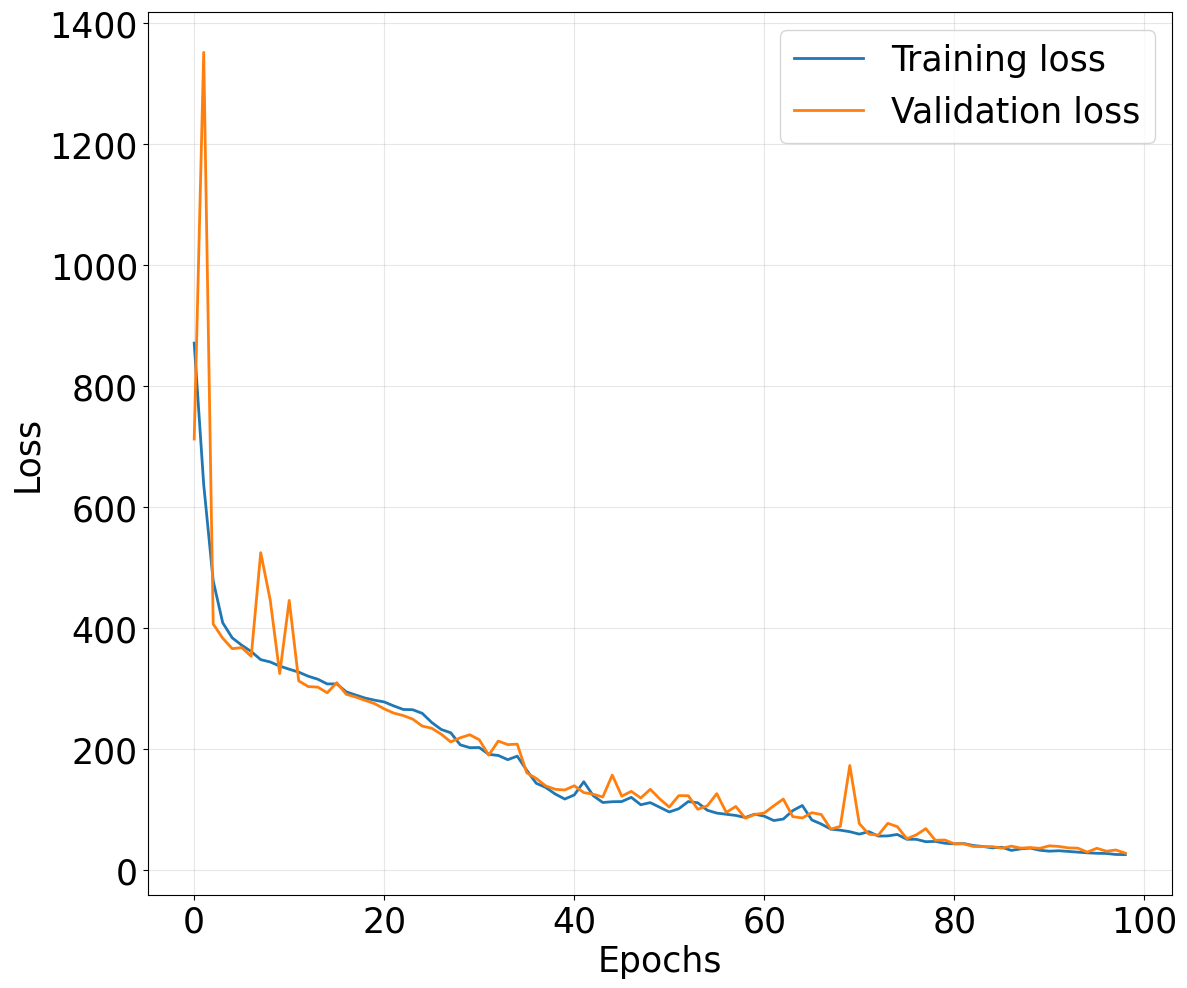

In [7]:
# Load the JSON file
with open('/sps/grand/macias/Sam_Result/multi_v2_CNN_100epochs_36samples/detailed_metrics.json', 'r') as f:
    data = json.load(f)

# Extract data
epochs = data['epochs']
train_loss = data['training_losses']
val_loss = data['validation_losses']
val_psnr = data['validation_psnr']
peak_to_peak = data['peak_to_peak_ratio']
learning_rate = data['learning_rates']

# Create single subplot (not 2x2)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
fontize = 25

# Plot 1: Training and Validation Loss
ax.plot(epochs, train_loss, label='Training loss', linewidth=2)
ax.plot(epochs, val_loss, label='Validation loss', linewidth=2)
ax.set_xlabel('Epochs', fontsize=fontize)
ax.set_ylabel('Loss', fontsize=fontize)
ax.legend(fontsize=fontize)
ax.tick_params(axis='both', labelsize=fontize)  # Both x and y ticks
ax.grid(True, alpha=0.3)

# Plot 2: Validation PSNR
# ax.plot(epochs, val_psnr, color='green', linewidth=2)
# ax.set_xlabel('Epochs', fontsize=12)
# ax.set_ylabel('PSNR', fontsize=12)
# ax.tick_params(axis='both', labelsize=12)  # Both x and y ticks
# # ax.set_title('Validation PSNR', fontsize=12)
# ax.grid(True, alpha=0.3)

# # Plot 3: Learning Rate
# ax.plot(epochs, learning_rate, color='cyan', linewidth=2)
# ax.set_xlabel('Epochs', fontsize=12)
# ax.set_ylabel('Learning Rate', fontsize=12)
# # ax.set_title('Learning Rate', fontsize=12)
# ax.tick_params(axis='both', labelsize=12)  # Both x and y ticks
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
# ax.grid(True, alpha=0.3)

# # Plot 4: Peak-to-Peak Ratio
# ax.plot(epochs, peak_to_peak, color='magenta', linewidth=2)
# ax.set_xlabel('Epochs', fontsize=12)
# ax.set_ylabel('Peak-to-Peak Amplitude', fontsize=12)
# # ax.set_title('Validation Peak-to-Peak', fontsize=12)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
# ax.grid(True, alpha=0.3)
# ax.tick_params(axis='both', labelsize=12)  # Both x and y ticks

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
plt.savefig('/pbs/home/o/omacias/Sam_project/raytune_lib_final/output/training_metrics.pdf', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

### Save

### Traces VS Frequency

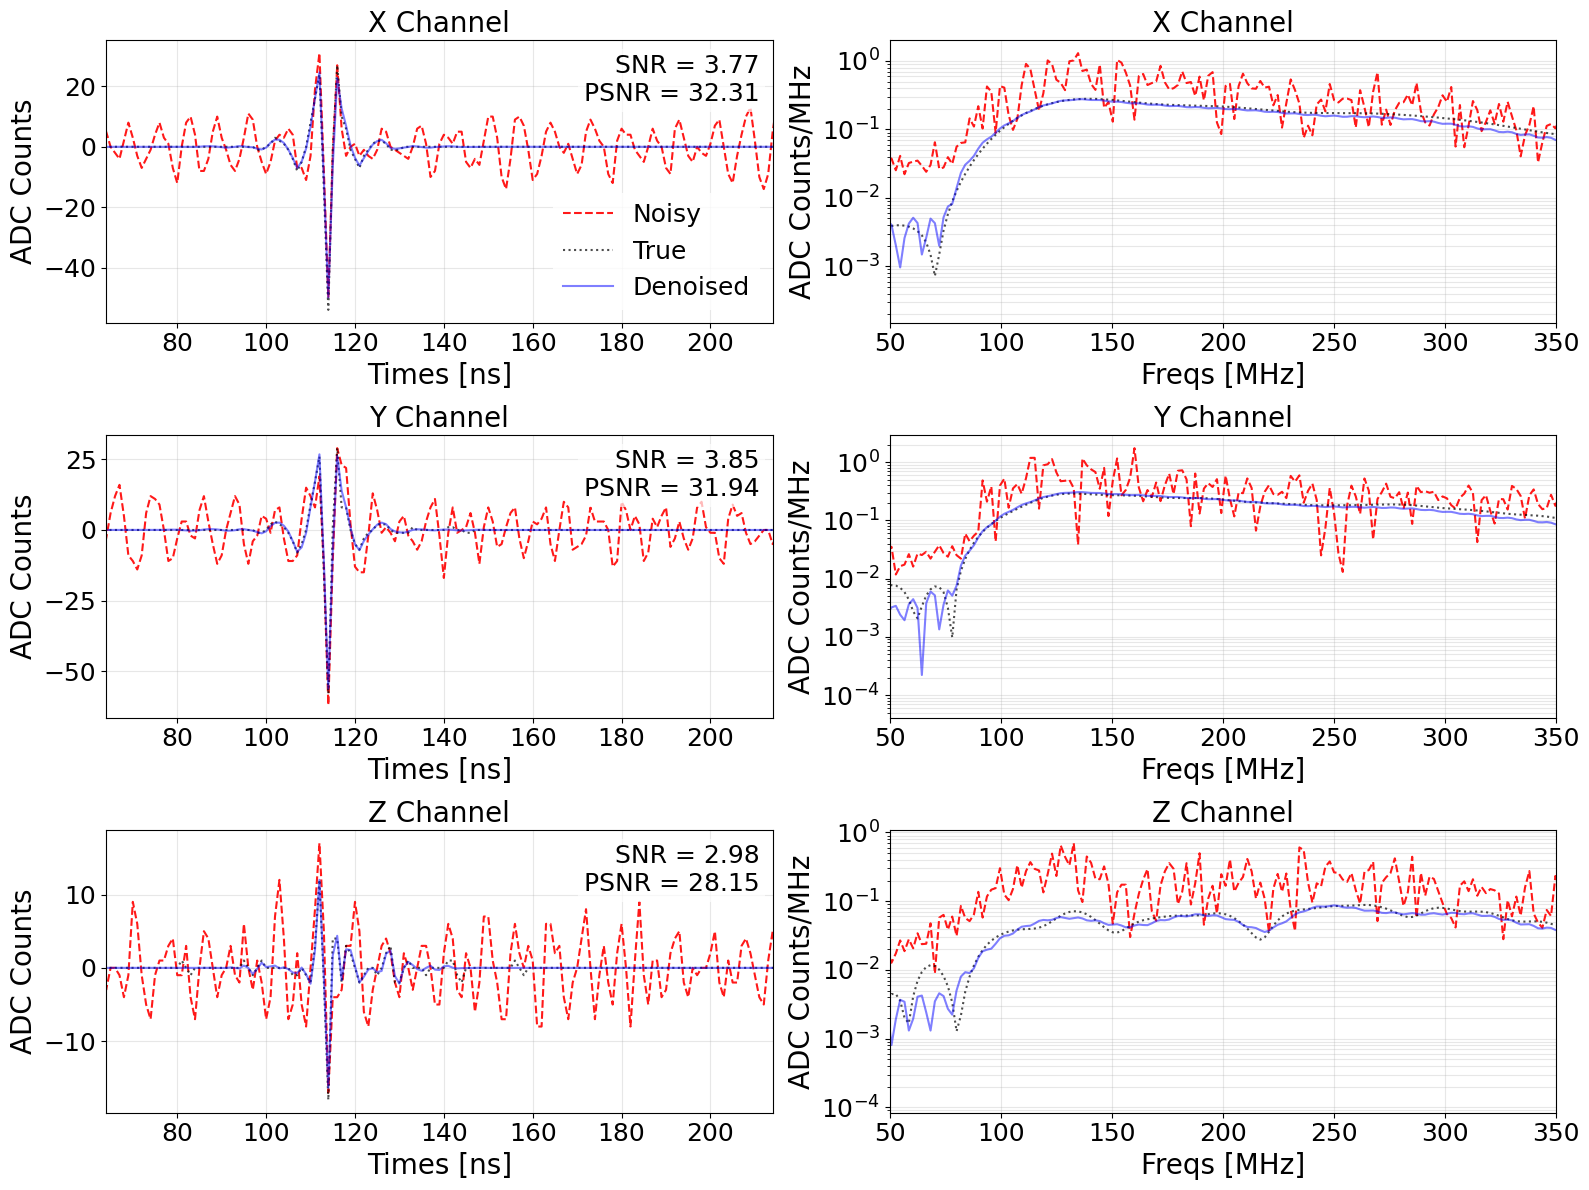

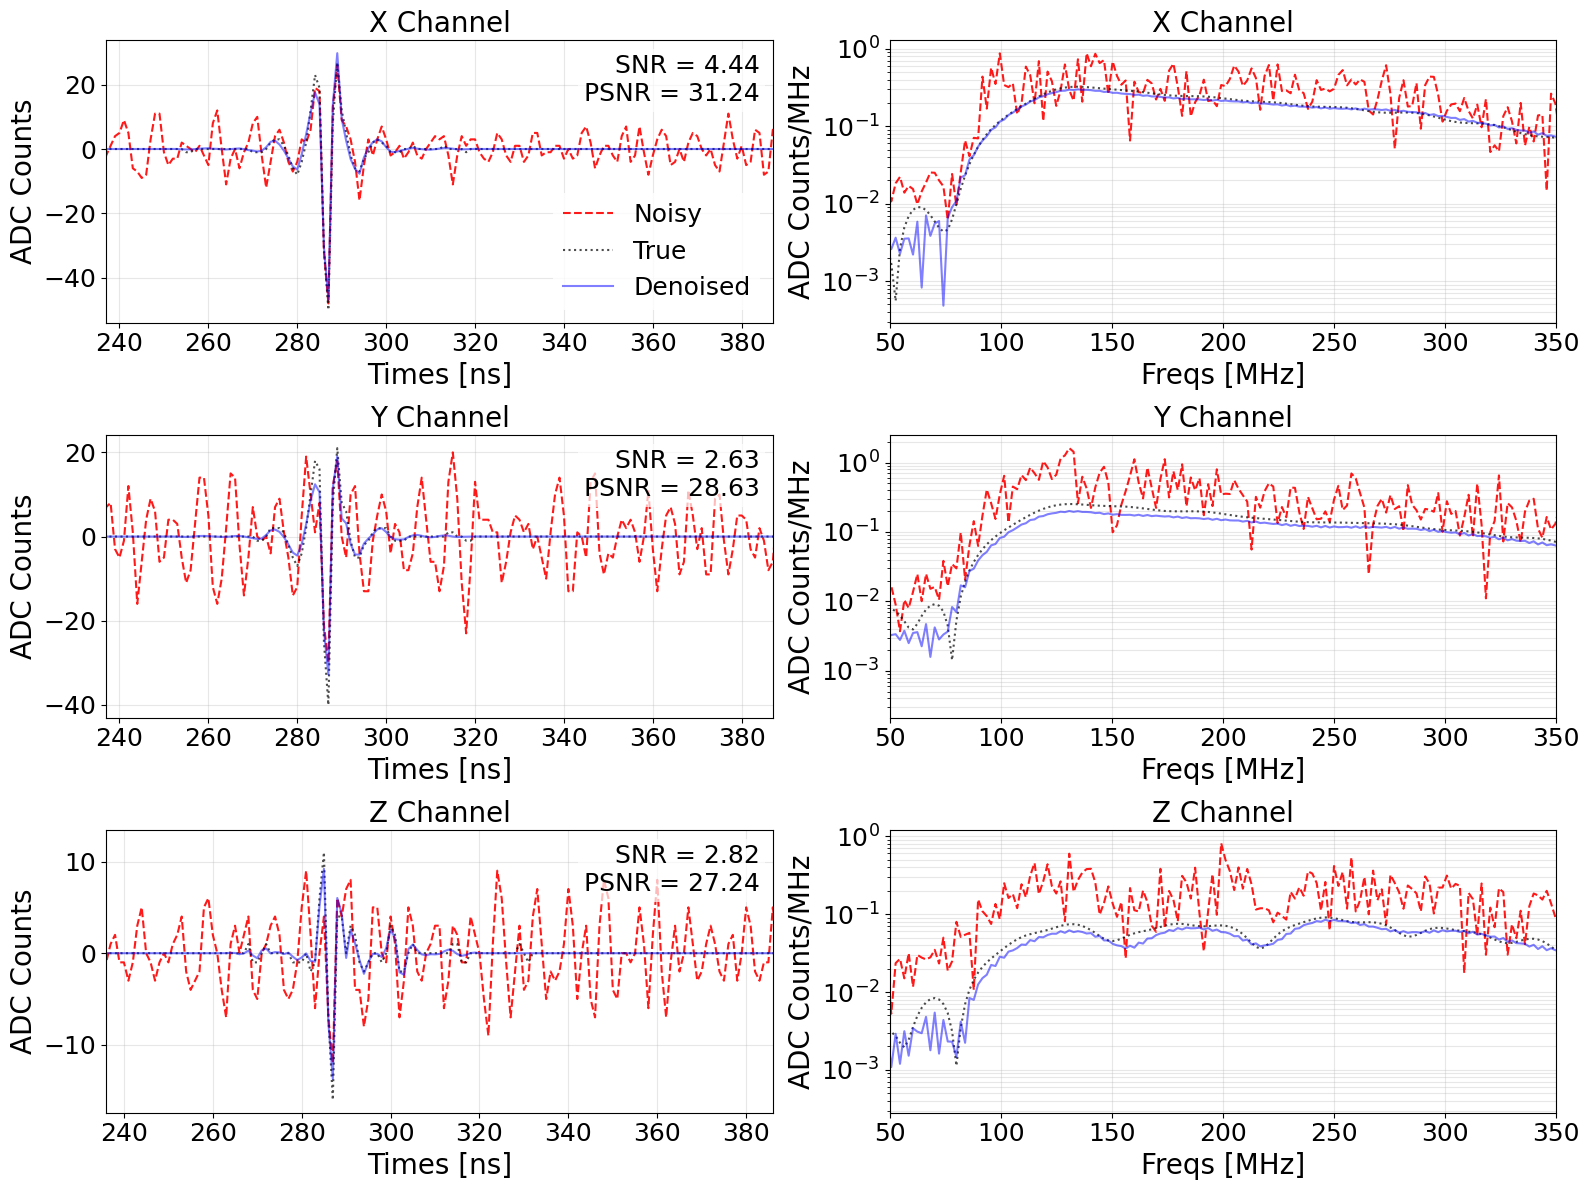

traces_plot_time_frequency completed. Generated 2 plots.


In [ ]:
traces_plot_time_frequency(
        testloader = test_loader,
        model = multi_l1_model,
        num_images=2,
        device="cpu",
        save_path=save_path,
        x_channel_snr = 4.0,
        y_channel_snr = 3.0,
        z_channel_snr = 2.0
    )

### Peak Time efficiency

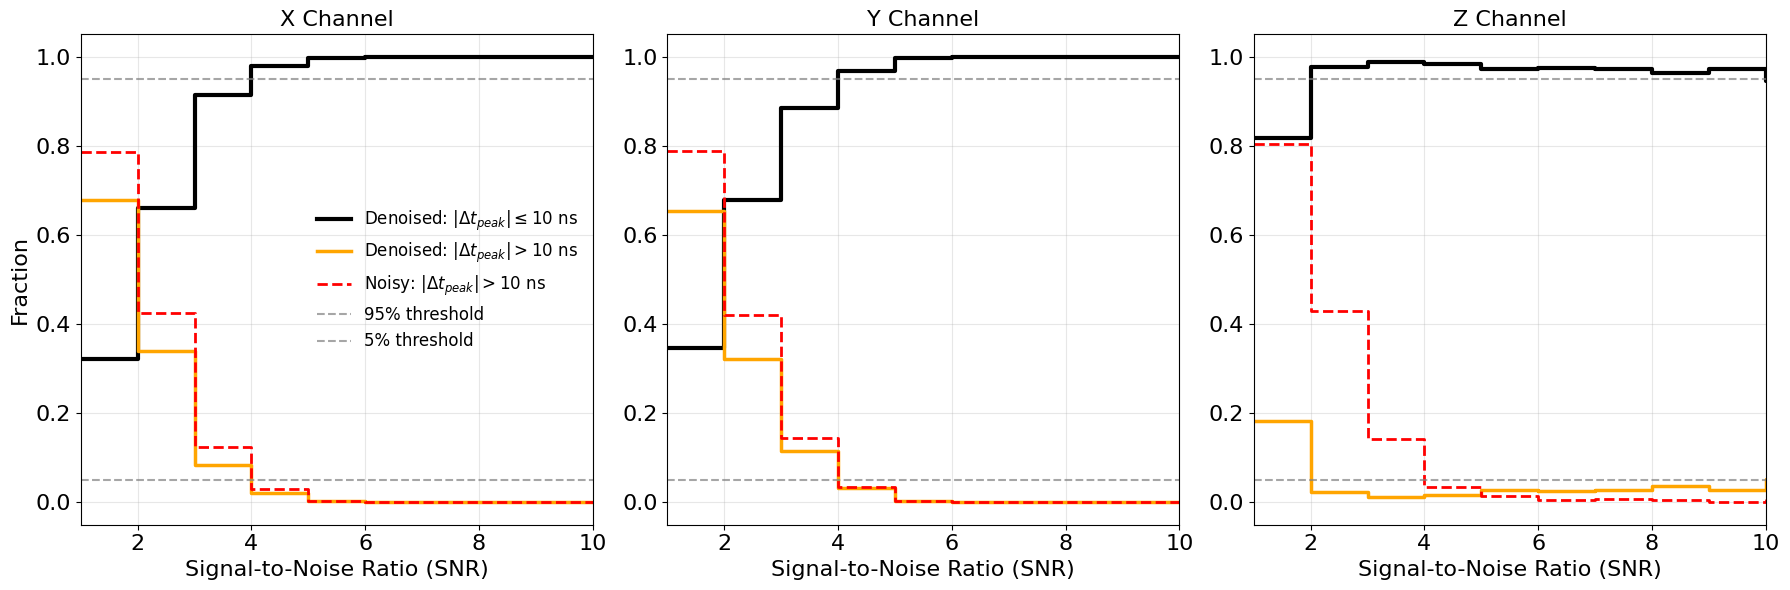

In [ ]:
peak_time_analysis_for_all_channels(dataloader = test_loader, 
                                    model = multi_l1_model,
                                    model_path = multi_l1_model_path,
                                    device = "cpu", 
                                    min_snr=1, 
                                    max_snr=1e3, 
                                    thresholds_list=[10], 
                                    save_path=save_path
                                    );

### Peak Amplitude Ratio

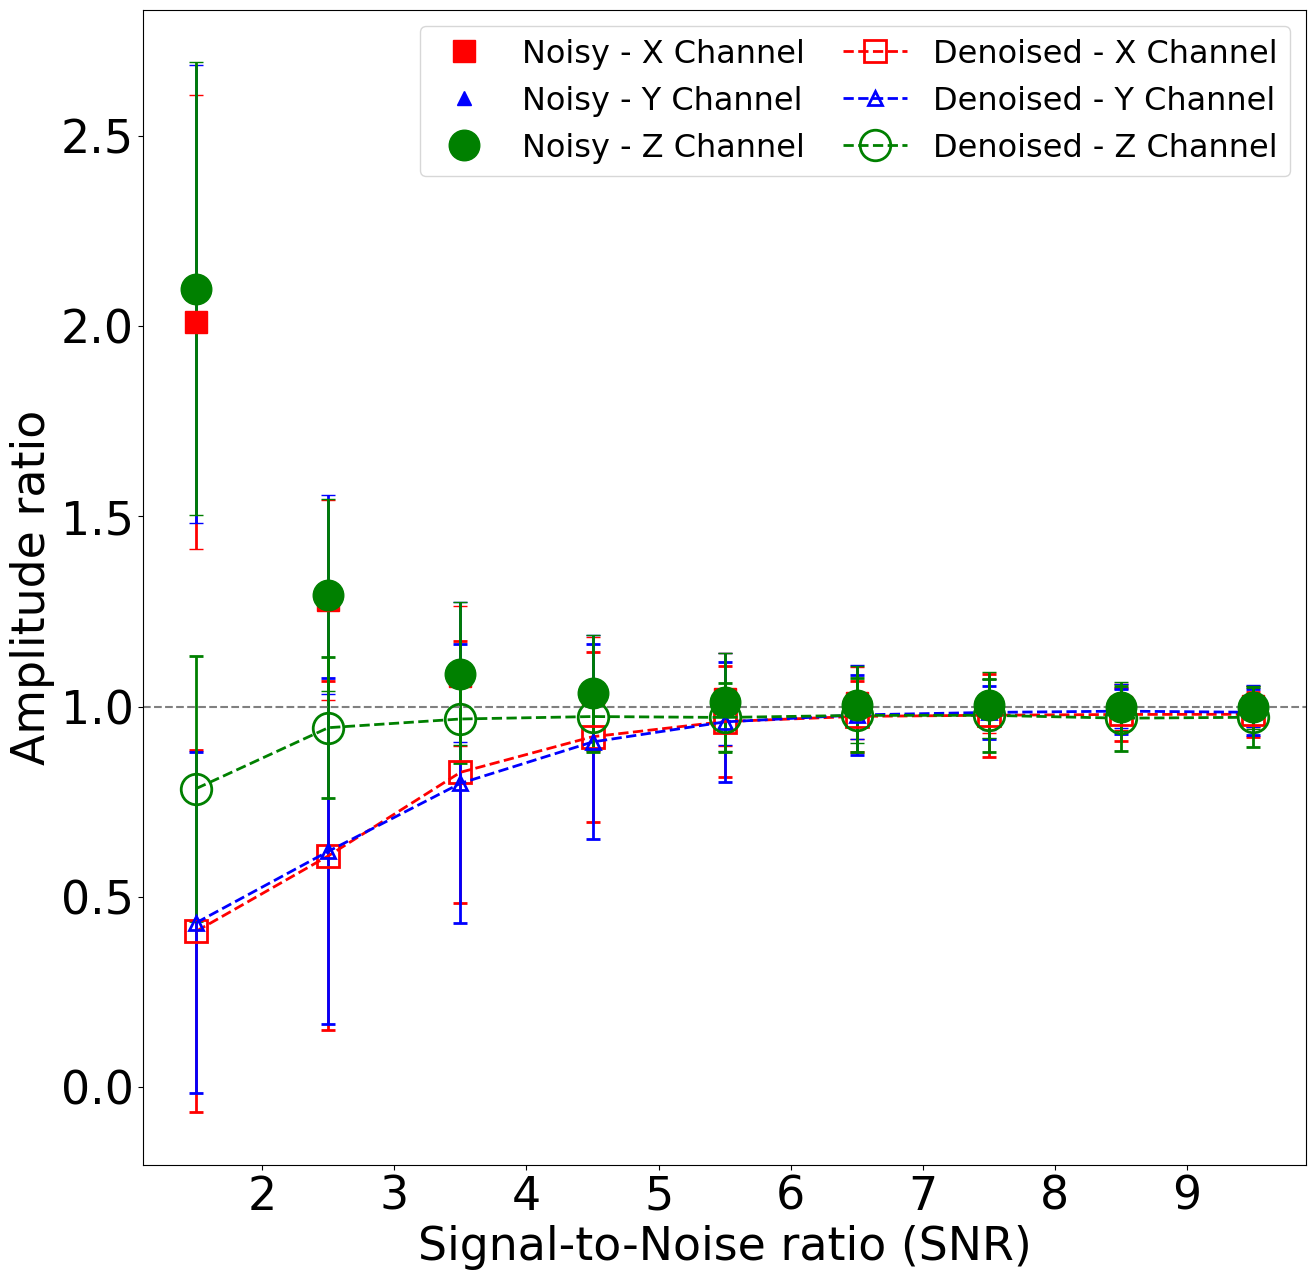

In [10]:
peak_amplitude_analysis_all_channels(
    dataloader=test_loader,
    model=multi_l1_model,
    model_path=multi_l1_model_path,
    device="cpu",
    save_path=save_path)

### Usable Antenna Versus SNR


Processed 1000 batches...
Processed 2000 batches...
Processed 3000 batches...
Processed 4000 batches...
Processed 5000 batches...
Processed 6000 batches...
Processed 7000 batches...
Processed 8000 batches...
Processed 9000 batches...
Processed 10000 batches...
Processed 11000 batches...
Processed 12000 batches...
Processed 13000 batches...
Processed 14000 batches...
Processed 15000 batches...
Processed 16000 batches...
Processed 17000 batches...
Processed 18000 batches...
Processed 19000 batches...
Processed 20000 batches...
Processed 21000 batches...
Processed 22000 batches...
Processed 23000 batches...
Processed 24000 batches...
Processed 25000 batches...
Processed 26000 batches...
Processed 27000 batches...
Processed 28000 batches...
Processed 29000 batches...
Processed 30000 batches...
Processed 31000 batches...
Processed 32000 batches...
Processed 33000 batches...
Processed 34000 batches...
Processed 35000 batches...
Processed 36000 batches...
Processed 37000 batches...
Processed 

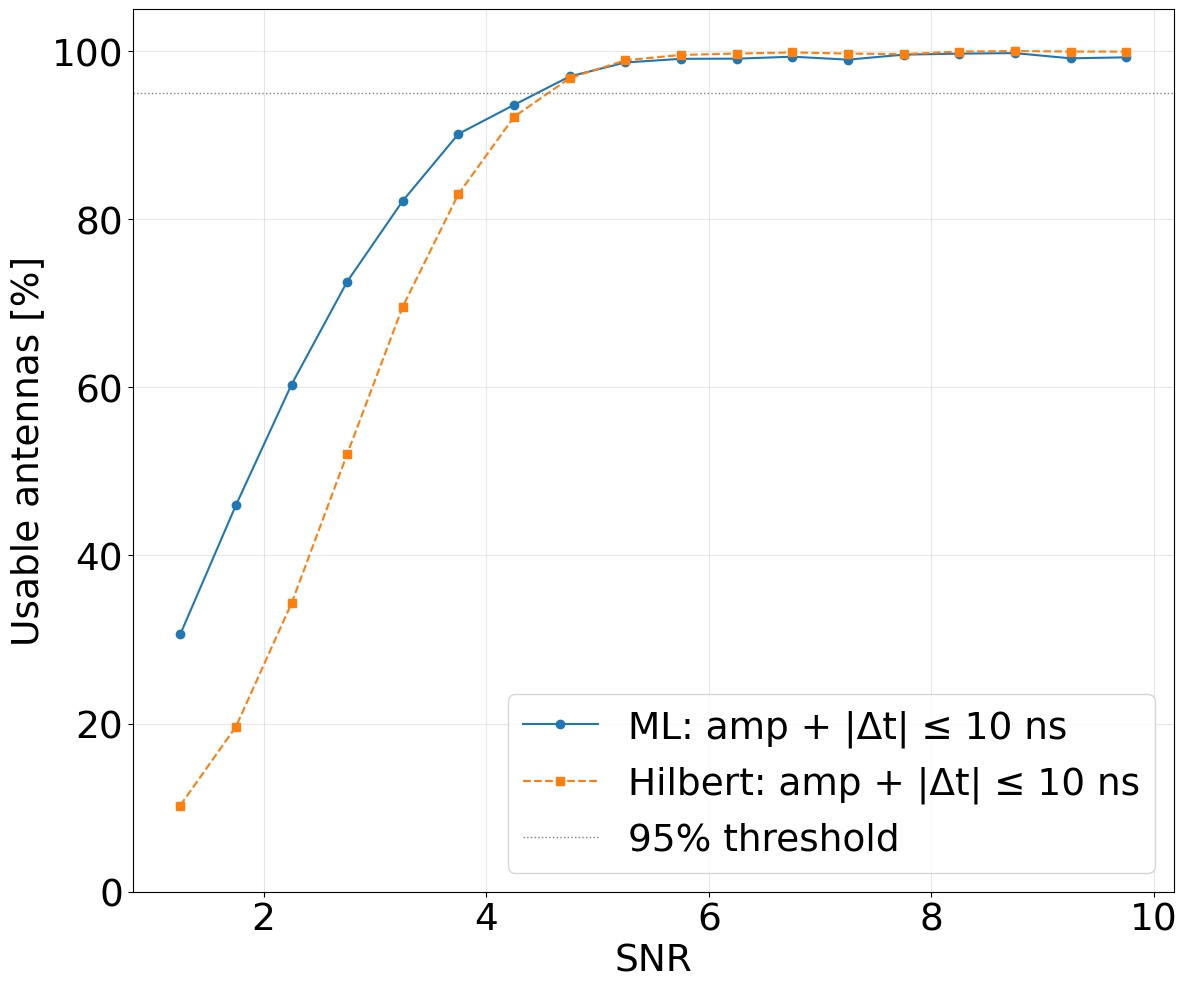

In [6]:
from evaluation.physics_impact.physics_impact import (
    plot_usable_antennas_single_panel,
    collect_traces_from_dataloader,
    load_best_trial_from_files
)
test_loader = DataLoader(test_dataset, batch_size=1, num_workers=0, shuffle=False, pin_memory=True)
clean_traces, noisy_traces, ml_traces, hilbert_traces, snr_values = \
    collect_traces_from_dataloader(test_loader, multi_l1_model, device)
    
results = plot_usable_antennas_single_panel(
    snr=snr_values,
    clean_traces=clean_traces,
    ml_traces=ml_traces,
    hilbert_traces=hilbert_traces,
    amp_threshold=2.0,
    t_max_ns_list=[10.0],
    dt_ns=1.0,
    snr_min=1.0,
    snr_max=10.0,
    snr_step=0.5,
    hilbert_label="Hilbert",
    save_path=save_path,
)

### nmse_snr_gain_vs_snr

Loading model...
Loading simulation data...
Loaded noise file 0: shape (3, 12500, 1024)


Noise signals shape: (3, 300000, 1024)
Clean signals shape: (3, 410673, 1024)
Using 41068 samples for evaluation
Running inference...
  Processed 500 batches...
Inference complete. Shape: (41068, 3, 512), SNR range: [0.32, 1775.21]
Inference complete. Shape: (41068, 3, 512), SNR range: [0.32, 1775.21]
Saved: /pbs/home/o/omacias/Sam_project/raytune_lib_final/output/fig_nmse_snrgain_vs_snr_option3.pdf


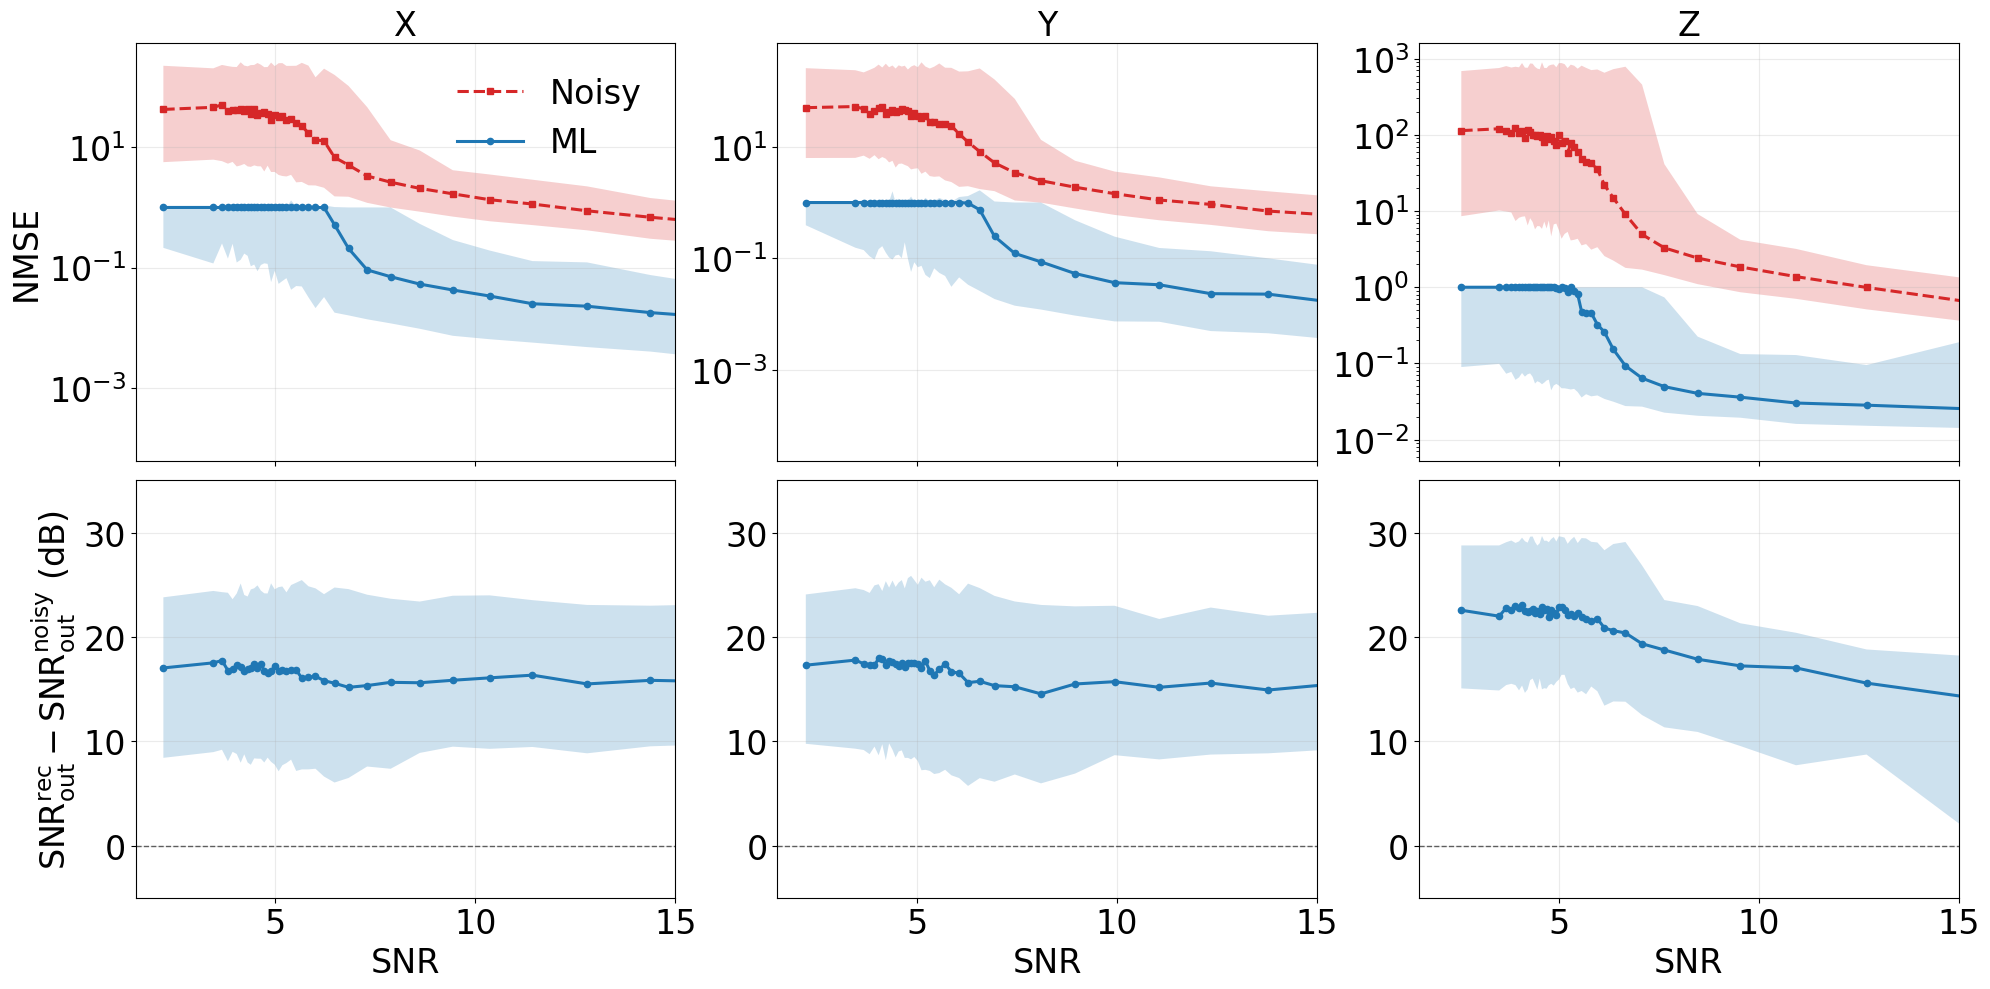

In [8]:
sys.path.insert(0, '/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization')
from nmse_snr_gain_vs_snr.make_fig_nmse_snr_gain_vs_snr__option3_truth_cleanpower_gate import (
    plot_nmse_and_snr_gain_vs_snr,
    FidelityPlotConfig
)
from common_ml_utils import load_data_and_run_inference

eval_pack = load_data_and_run_inference(
    model_path=multi_l1_model_path,
    metrics_json=multi_l1_metrics_json,
    config_json=multi_l1_config_json,
    data_path="/sps/grand/blevy/sims/sims_for_denoising_sept2025",
    device="cpu",
    batch_size=64,
    max_samples=None,
)

clean = eval_pack.clean        # (N, 3, T)
noisy = eval_pack.noisy        # (N, 3, T)
denoised = eval_pack.denoised  # (N, 3, T)
# standard = np.abs(hilbert(noisy, axis=-1)).astype(np.float32)

save_path = '/pbs/home/o/omacias/Sam_project/raytune_lib_final/output/fig_nmse_snrgain_vs_snr_option3.pdf'

cfg = FidelityPlotConfig(
    dt_ns=2.0,
    roi_half_width_ns=150.0,
    snr_peak_half_width_ns=150.0,
    snr_exclude_half_width_ns=150.0,
    rolling_window=400,
    rolling_min_points=80,
    rolling_grid=45,
    clean_power_gate_quantile=0.10,
    clean_power_gate_min_count=200,
    band_quantiles=(0.05, 0.95),
    xlim=(1.5, 15.0),
    savepath=save_path,
    dpi=220,
)


plot_nmse_and_snr_gain_vs_snr(
    clean_waveforms=clean,
    noisy_waveforms=noisy,
    denoised_waveforms=denoised,
    snr=None,
    cfg=cfg,
)

Loaded noise file 0: shape (3, 12500, 1024)
Noise signals shape: (3, 300000, 1024)
Clean signals shape: (3, 410673, 1024)
Loading model...
Loading simulation data...
Loaded noise file 0: shape (3, 12500, 1024)
Noise signals shape: (3, 300000, 1024)
Clean signals shape: (3, 410673, 1024)
Using 41068 samples for evaluation
Running inference...
  Processed 500 batches...
Inference complete. Shape: (41068, 3, 512), SNR range: [0.31, 2049.72]
Inference complete. Shape: (41068, 3, 512), SNR range: [0.31, 2049.72]


/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization/plot_usable_antenna_vs_SNR/make_fig_event_multiplicity_usable_nmse.py:582: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="upper left", frameon=False, fontsize=fontsize)


Saved: /pbs/home/o/omacias/Sam_project/raytune_lib_final/output/fig_nmse_snrgain_vs_snr_option3.pdf


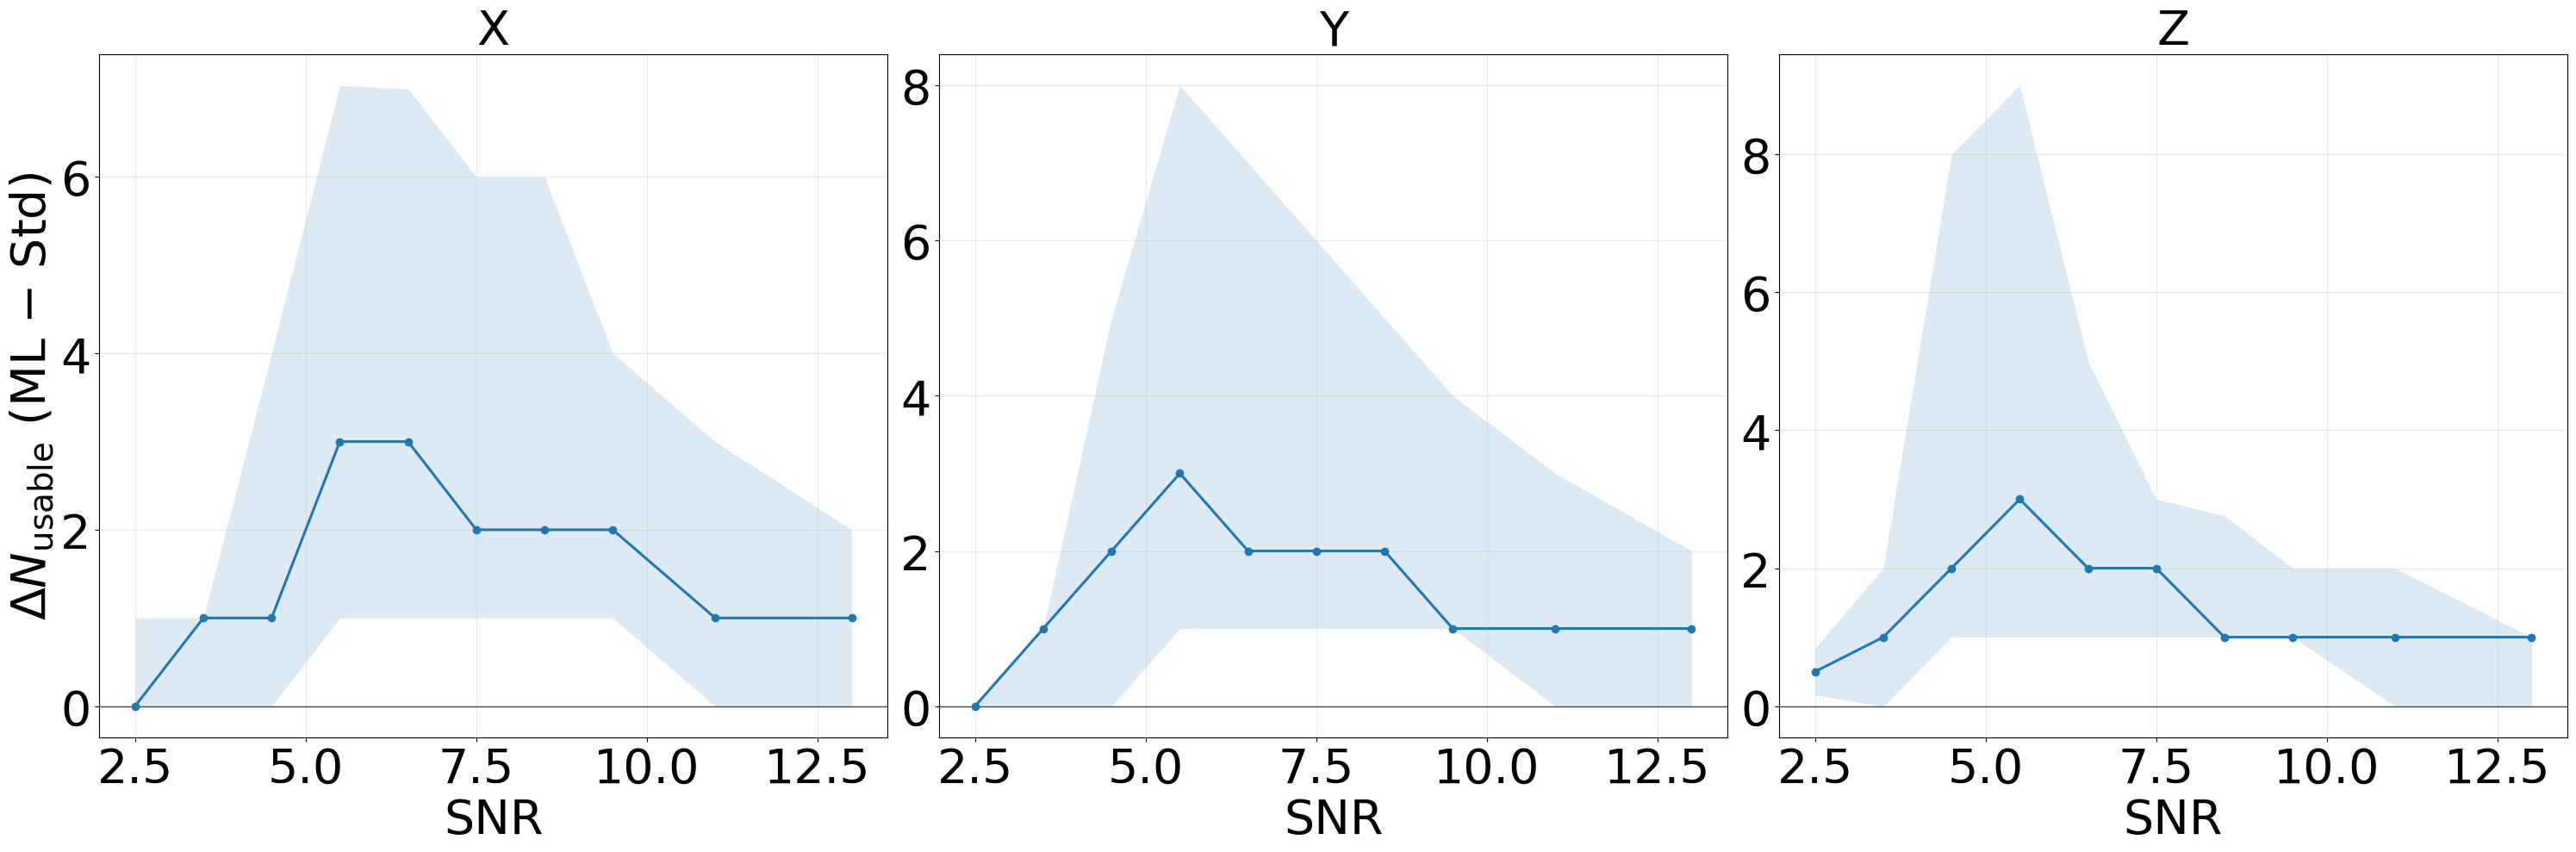

{'snr_trace': array([[  5.30724259,   6.19052946,   5.66463792],
        [ 13.03569921,   4.59004262,   5.94272364],
        [  4.97127766,   7.5429554 ,   4.649515  ],
        ...,
        [102.089502  ,  34.14816447,  37.67392581],
        [ 91.27445683,  29.46330178,  55.93765049],
        [  5.64184911,   4.37577645,   5.46737906]]),
 'A_noisy': array([[ 18.56794199,  26.81052469,  12.88419472],
        [ 41.05810503,  17.65254903,  13.91147304],
        [ 15.9491376 ,  24.93506156,   8.6219922 ],
        ...,
        [377.06287305, 142.52495273,  87.35571757],
        [364.54635577, 103.39061747, 131.68693599],
        [ 19.89634575,  16.55918107,  12.15454847]]),
 'sigma_env': array([[3.49860434, 4.33089365, 2.27449572],
        [3.14966649, 3.84583554, 2.34092545],
        [3.20825725, 3.30574162, 1.85438529],
        ...,
        [3.69345394, 4.17372222, 2.31873148],
        [3.9939581 , 3.50913208, 2.35417353],
        [3.52656467, 3.78428406, 2.22310331]]),
 'trigger_mask': a

In [ ]:
import sys
sys.path.insert(0, '/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization')
from plot_usable_antenna_vs_SNR.make_fig_event_multiplicity_usable_nmse import (
    plot_event_multiplicity_usable_nmse,
    EventMultiplicityConfig
)
data_path = "/sps/grand/blevy/sims/sims_for_denoising_sept2025"
_, clean_signals = produce_noise_and_noiseless_data(data_path)
total_samples = clean_signals.shape[1]
train_indices, valid_indices, test_indices = split_indices(
    total_samples, train_frac=0.8, valid_frac=0.1
)


max_samples = None
if max_samples is not None:
    indices_used = test_indices[:max_samples]
else:
    indices_used = test_indices
event_number_list_path = os.path.join(data_path, "event_number_list.npy")
event_ids_full = np.load(event_number_list_path)
event_ids = event_ids_full[indices_used]
eval_pack = load_data_and_run_inference(
    model_path=multi_l1_model_path,
    metrics_json=multi_l1_metrics_json,
    config_json=multi_l1_config_json,
    data_path="/sps/grand/blevy/sims/sims_for_denoising_sept2025",
    device="cpu",
    batch_size=64,
    max_samples=None,
)
clean = eval_pack.clean        # (N, 3, T)
noisy = eval_pack.noisy        # (N, 3, T)
denoised = eval_pack.denoised  # (N, 3, T)
standard_waveforms = noisy

cfg = EventMultiplicityConfig(
        dt_ns=2.0,
        eps=1e-12,
        roi_half_width_ns=150.0,
        snr_peak_half_width_ns=150.0,
        snr_exclude_half_width_ns=150.0,
        mad_scale_gaussian=1.4826022185056,
        apply_bandpass_to_snr=True,
        apply_trigger=False,
        trigger_k_sigma=1.0,
        apply_bandpass=True,
        f_lo_hz=50e6,
        f_hi_hz=200e6,
        butter_order=4,
        apply_clean_power_gate=True,
        clean_power_gate_quantile=0.10,
        clean_power_gate_min_count=200,
        clean_power_gate_abs_floor=0,
        snr_calib_min=6.0,
        calib_pass_rate=0.95,
        event_snr_stat='median',
        snr_bins=(1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14),
        band_quantiles=(0.16, 0.84),
        channel_names=['X', 'Y', 'Z'],
        labels=["Standard", "ML"],
        colors=["C1", "k"],
        band_alpha=0.18,
        ylim_counts=None,
        ylim_delta=None,
        savepath=save_path,
        dpi=220,
    )

plot_event_multiplicity_usable_nmse(
        clean_waveforms=clean,
        noisy_waveforms=noisy,
        denoised_waveforms=denoised,
        standard_waveforms=standard_waveforms,
        event_ids=event_ids,
        extra_base_mask=None,
        cfg=cfg
    );

###  NMSE vs SNR

Saved: /pbs/home/o/omacias/Sam_project/raytune_lib_final/output


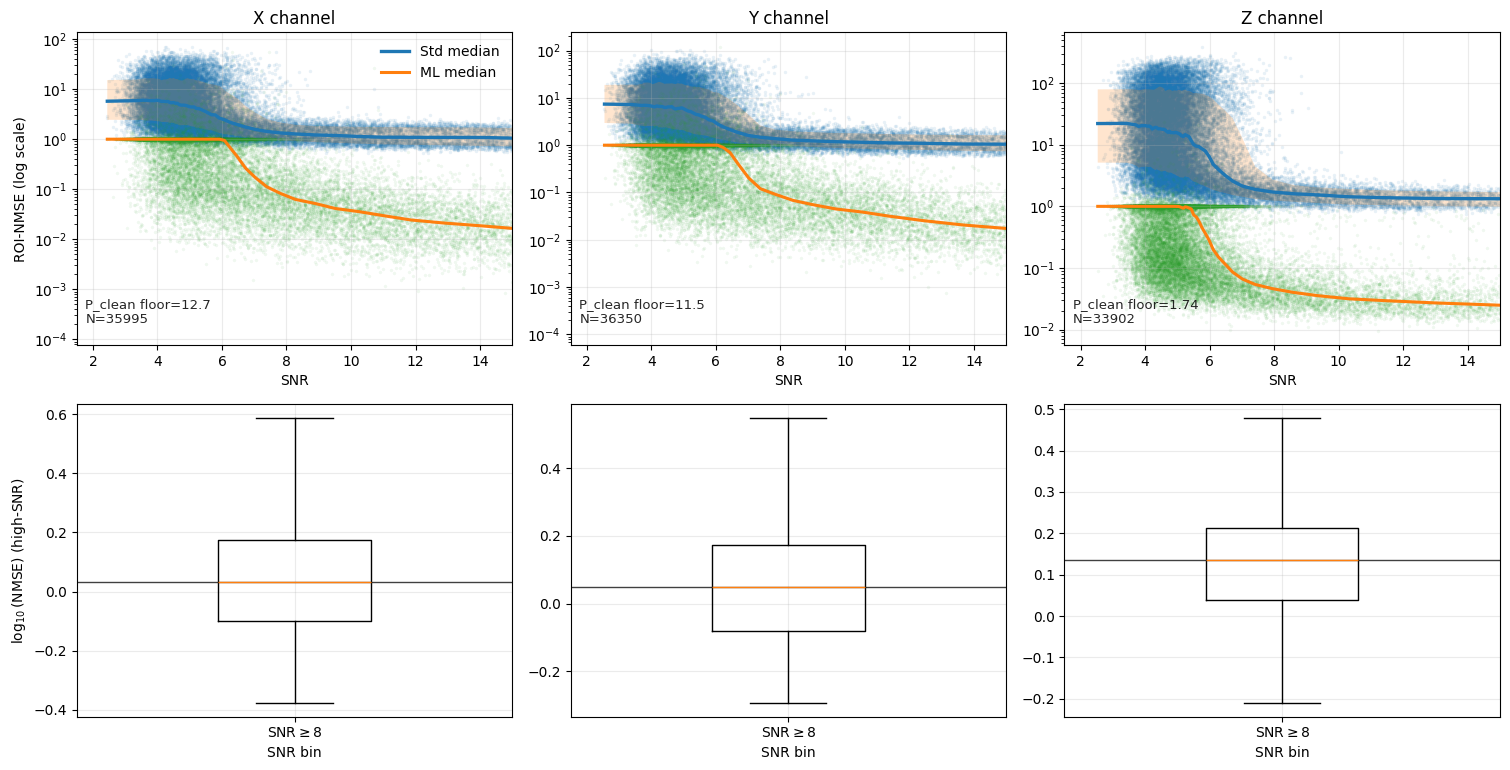

In [9]:
from NMSE_STD_VS_SNR.make_fig_appendix_check1_nmse_std_vs_snr import run_in_notebook as run_in_notebook_nmse_vs_snr

clean_list = []
noisy_list = []
denoised_list = []

multi_l1_model.eval()
with torch.no_grad():
    for batch_idx, (noisy_batch, clean_batch) in enumerate(test_loader):
        noisy_batch = noisy_batch.to(device)
        denoised_batch = multi_l1_model(noisy_batch)
        
        clean_list.append(clean_batch.numpy())
        noisy_list.append(noisy_batch.cpu().numpy())
        denoised_list.append(denoised_batch.cpu().numpy())

clean = np.concatenate(clean_list, axis=0)      # (N, 3, T)
noisy = np.concatenate(noisy_list, axis=0)      # (N, 3, T)
denoised = np.concatenate(denoised_list, axis=0) # (N, 3, T)
standard = np.abs(hilbert(noisy, axis=-1)).astype(np.float32)

results = run_in_notebook_nmse_vs_snr(
    clean=clean,
    noisy=noisy,
    standard=standard,
    ml=denoised,
    savepath=save_path,
    show_ml_overlay=True,
    high_snr_min=8.0,
);

### Comparing Multi-MSE & Multi-L1

Running Low SNR Analysis (1 < SNR < 4)...


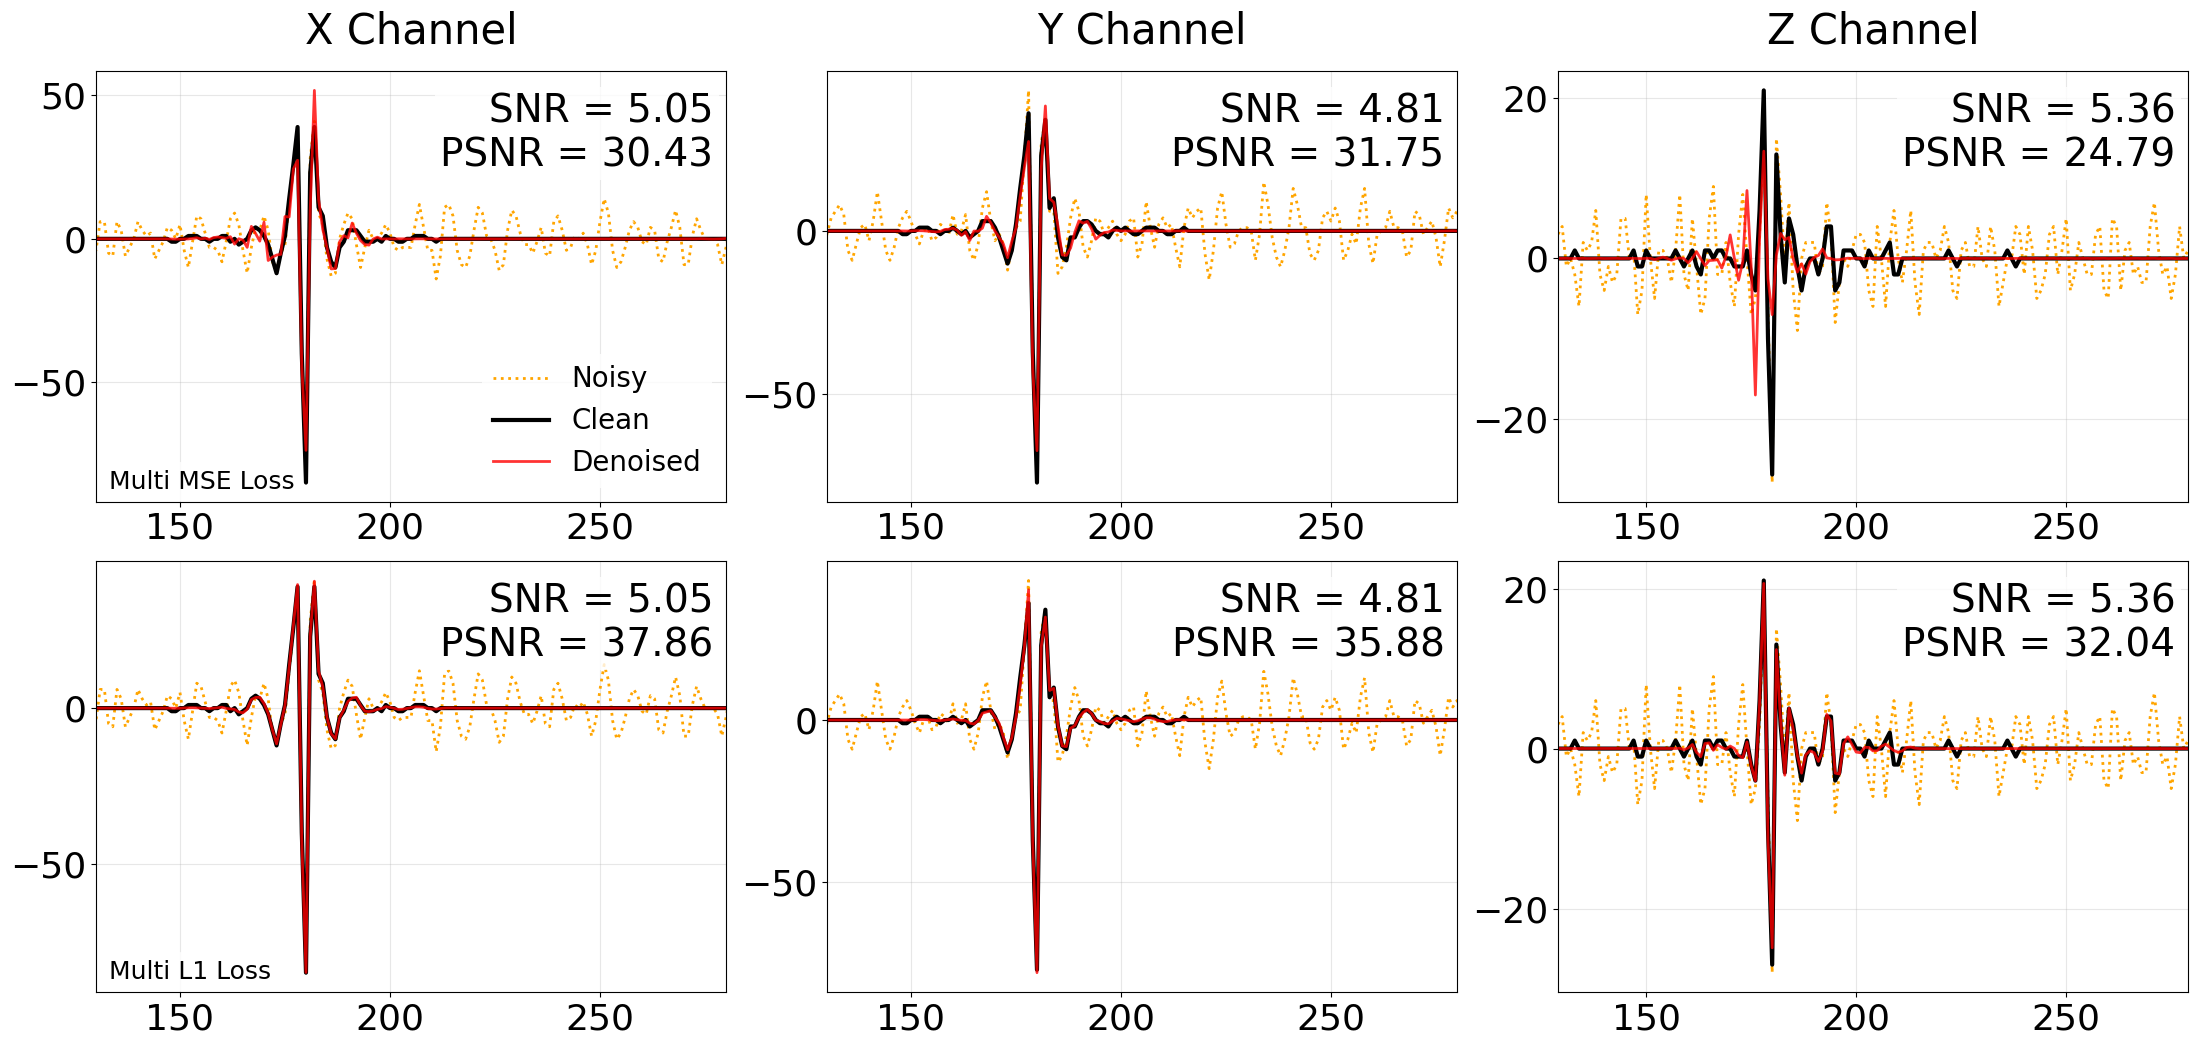

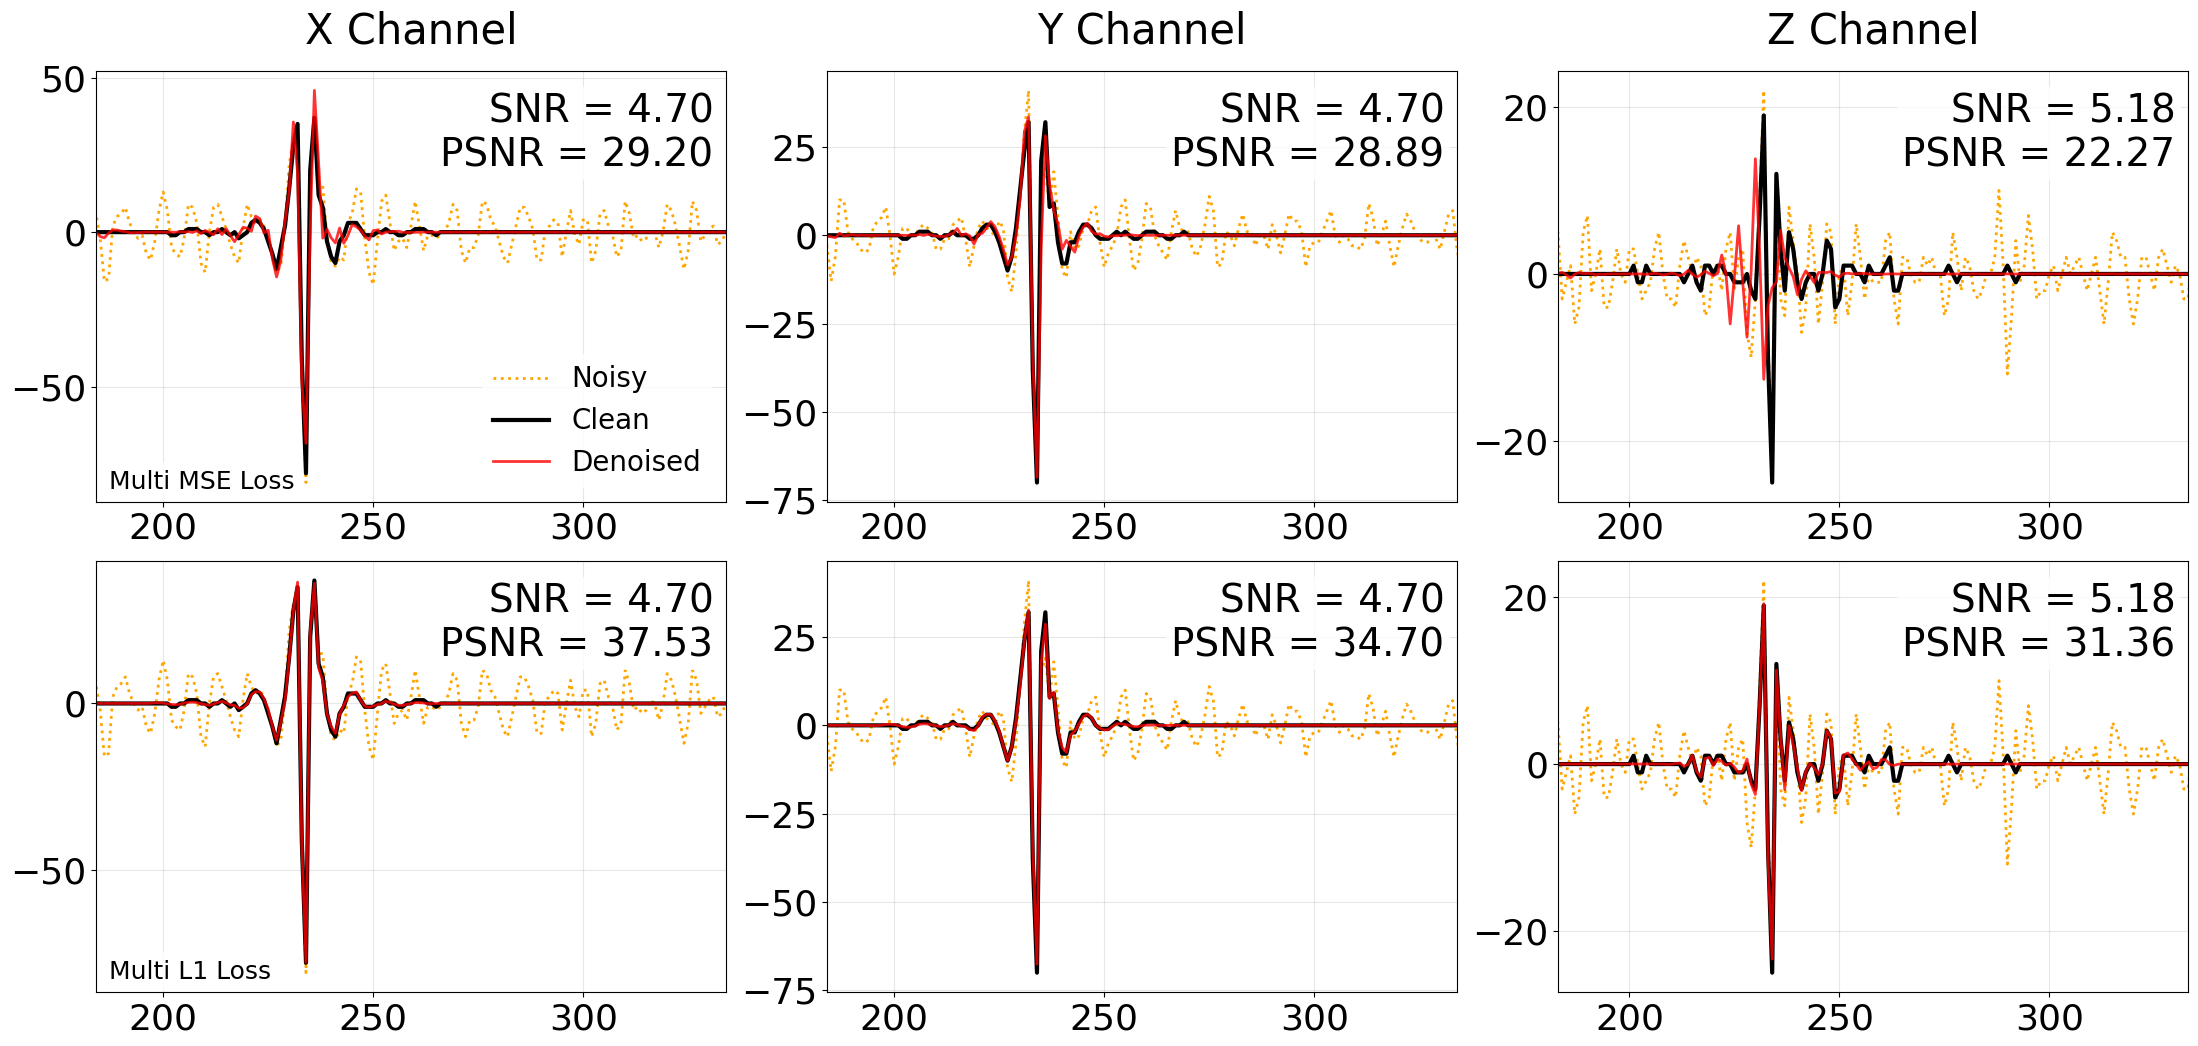

Traces comparison completed


In [10]:
from visualization.overleaf_plots import load_models_v2, traces_plot_comparison

model_classes = {"CNN": CNN}

model_paths = {
    'Multi MSE Loss': (
        multi_mse_metrics_json,
        multi_mse_config_json,
        multi_mse_model_path
    ),
    'Multi L1 Loss': (
        multi_l1_metrics_json,
        multi_l1_config_json,
        multi_l1_model_path
    )
}

models = load_models_v2(model_paths, model_classes, device='cpu')
save_path = "/pbs/home/o/omacias/Sam_project/raytune_lib_sept25"
# --- Low SNR Analysis (1 < SNR < 4) ---
print("Running Low SNR Analysis (1 < SNR < 4)...")

traces_plot_comparison(testloader = test_loader, 
                models = models, 
                num_images = 2, 
                device="cpu", 
                save_path = save_path,
                snr_min=4,
                snr_max=6,
                peak_amp_threshold=5)